# Dự Báo Q2/2026 — Thống Nhất Bike

Notebook này phân tích dữ liệu bán hàng từ 2025-01 đến 2026-02 và dự báo cho Q2/2026 (Tháng 4, 5, 6/2026).

**Ba câu hỏi chính:**
1. Dự báo doanh số Q2/2026 theo nhóm sản phẩm
2. Phân tích màu sắc & SKU trending
3. Dự báo hoạt động đại lý (RFM + Churn)

**Nguồn dữ liệu:** fact_sales.csv, sales_order.csv, order_line.csv, email_log.csv  
**Giai đoạn sạch:** Jan-Mar 2025, Jan-Feb 2026 (5 tháng)

---
## SECTION 0: Cài Đặt & Tải Dữ Liệu

In [1]:
# ── Thư viện chuẩn ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Cấu hình biểu đồ (theo style template Store-Item-Demand-Forecasting) ────
sns.set_theme(style='ticks', palette='muted')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0', '#00BCD4']
COLOR_PRIMARY = '#233D4D'
COLOR_ACCENT  = '#386B7F'
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
})

DATA_DIR = '/home/user/10tr_devided_by_-/data'
print('Thư viện đã tải thành công.')

Thư viện đã tải thành công.


In [2]:
# ── Tải dữ liệu ─────────────────────────────────────────────────────────────
fact_sales  = pd.read_csv(f'{DATA_DIR}/fact_sales.csv',  low_memory=False)
sales_order = pd.read_csv(f'{DATA_DIR}/sales_order.csv', low_memory=False)
order_line  = pd.read_csv(f'{DATA_DIR}/order_line.csv',  low_memory=False)
email_log   = pd.read_csv(f'{DATA_DIR}/email_log.csv',   low_memory=False)

print(f'fact_sales   : {fact_sales.shape}')
print(f'sales_order  : {sales_order.shape}')
print(f'order_line   : {order_line.shape}')
print(f'email_log    : {email_log.shape}')

fact_sales   : (35194, 24)
sales_order  : (2759, 14)
order_line   : (35194, 8)
email_log    : (1132, 7)


In [3]:
# ── Giải mã product_code → các cột phân loại ────────────────────────────────
GROUP_MAP = {'002': 'Xe thường', '003': 'Địa hình', '004': 'Gấp', '005': 'Điện'}

fact_sales['product_code'] = fact_sales['product_code'].astype(str).str.zfill(15)
fact_sales['model_code']   = fact_sales['product_code'].str[3:6]
fact_sales['group_code']   = fact_sales['product_code'].str[6:9]
fact_sales['color_code']   = fact_sales['product_code'].str[9:12]
fact_sales['size_code']    = fact_sales['product_code'].str[12:15]
fact_sales['group_name']   = fact_sales['group_code'].map(GROUP_MAP).fillna('Khác')

# Chuyển đổi kiểu ngày
fact_sales['order_date'] = pd.to_datetime(fact_sales['order_date'])
fact_sales['month_period'] = fact_sales['order_date'].dt.to_period('M')
fact_sales['week_period']  = fact_sales['order_date'].dt.to_period('W')

# ── Lọc dữ liệu sạch: loại 2026-03 (email only) và seg2='00U' ───────────────
df_clean = fact_sales[
    (fact_sales['month_period'] != pd.Period('2026-03', 'M')) &
    (fact_sales['group_code'] != '00U')
].copy()

print(f'Dữ liệu sạch: {len(df_clean):,} dòng')
print(f'Giai đoạn   : {df_clean["order_date"].min().date()} → {df_clean["order_date"].max().date()}')
print(f'Nhóm sản phẩm: {df_clean["group_name"].value_counts().to_dict()}')

# Thống kê doanh thu theo tháng
monthly_rev = df_clean.groupby('month_period')['line_total'].sum().reset_index()
monthly_rev.columns = ['month_period', 'revenue']
monthly_rev['month_str'] = monthly_rev['month_period'].astype(str)
monthly_rev['revenue_b'] = monthly_rev['revenue'] / 1e9
print('\nDoanh thu theo tháng (tỷ VND):')
print(monthly_rev[['month_str', 'revenue_b']].to_string(index=False))

Dữ liệu sạch: 34,062 dòng
Giai đoạn   : 2025-01-02 → 2026-02-28
Nhóm sản phẩm: {'Xe thường': 25106, 'Địa hình': 5038, 'Điện': 1930, 'Gấp': 1048, 'Khác': 940}

Doanh thu theo tháng (tỷ VND):
month_str  revenue_b
  2025-01   6.396341
  2025-02  12.674423
  2025-03  37.163580
  2026-01  42.270147
  2026-02  38.777738


---
## SECTION 1: CÂU HỎI 1 — Dự Báo Doanh Số Q2/2026

*Phương pháp: YoY ratio + trend extrapolation dựa trên 5 tháng dữ liệu sạch*

### 1.1 — EDA: Xu hướng doanh thu theo tháng

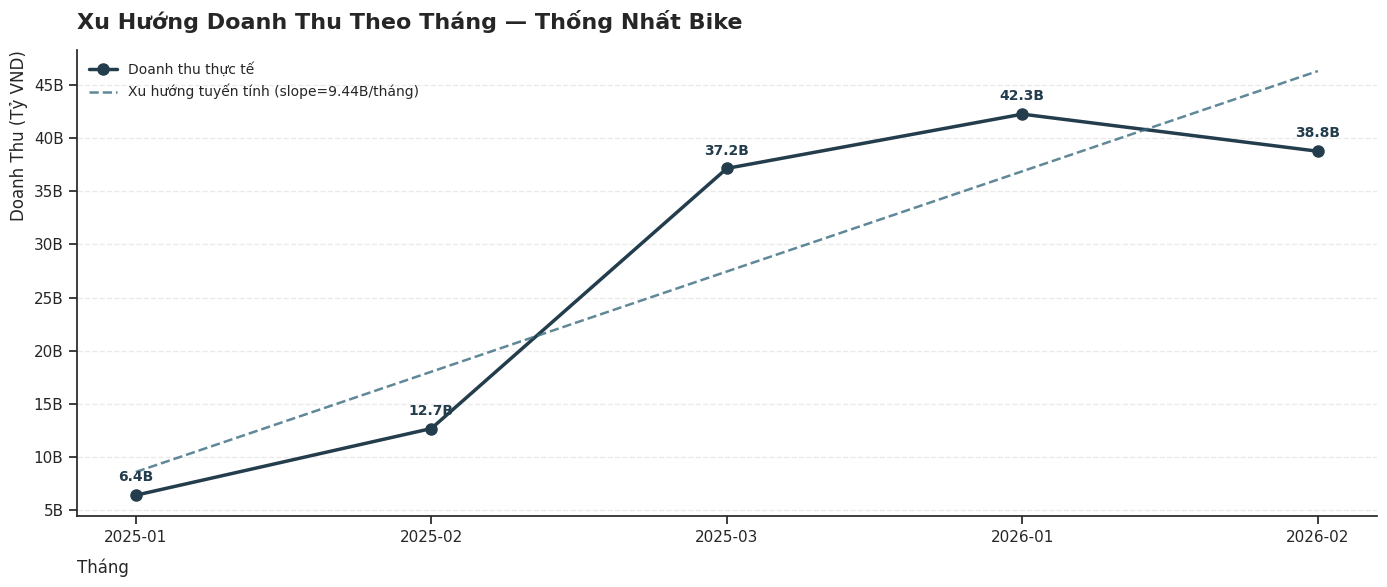


Tăng trưởng trung bình: 9.44 tỷ/tháng
Tổng doanh thu 5 tháng sạch: 137.3 tỷ VND


In [4]:
# ── Cell 1.1: Biểu đồ xu hướng doanh thu tháng ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

months_label = monthly_rev['month_str'].tolist()
revenues_b   = monthly_rev['revenue_b'].tolist()

ax.plot(months_label, revenues_b, marker='o', color=COLOR_PRIMARY,
        linewidth=2.5, markersize=8, label='Doanh thu thực tế')

# Trendline (linear regression)
x_idx = np.arange(len(months_label))
z = np.polyfit(x_idx, revenues_b, 1)
p = np.poly1d(z)
ax.plot(months_label, p(x_idx), '--', color=COLOR_ACCENT,
        linewidth=1.8, alpha=0.8, label=f'Xu hướng tuyến tính (slope={z[0]:.2f}B/tháng)')

# Chú thích giá trị
for i, (m, v) in enumerate(zip(months_label, revenues_b)):
    ax.annotate(f'{v:.1f}B', xy=(i, v), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold', color=COLOR_PRIMARY)

ax.set_title('Xu Hướng Doanh Thu Theo Tháng — Thống Nhất Bike',
             fontsize=16, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('Tháng', loc='left', labelpad=10)
ax.set_ylabel('Doanh Thu (Tỷ VND)', loc='top')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.4, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nTăng trưởng trung bình: {z[0]:.2f} tỷ/tháng')
print(f'Tổng doanh thu 5 tháng sạch: {sum(revenues_b):.1f} tỷ VND')

### 1.2 — EDA: Doanh thu theo nhóm sản phẩm

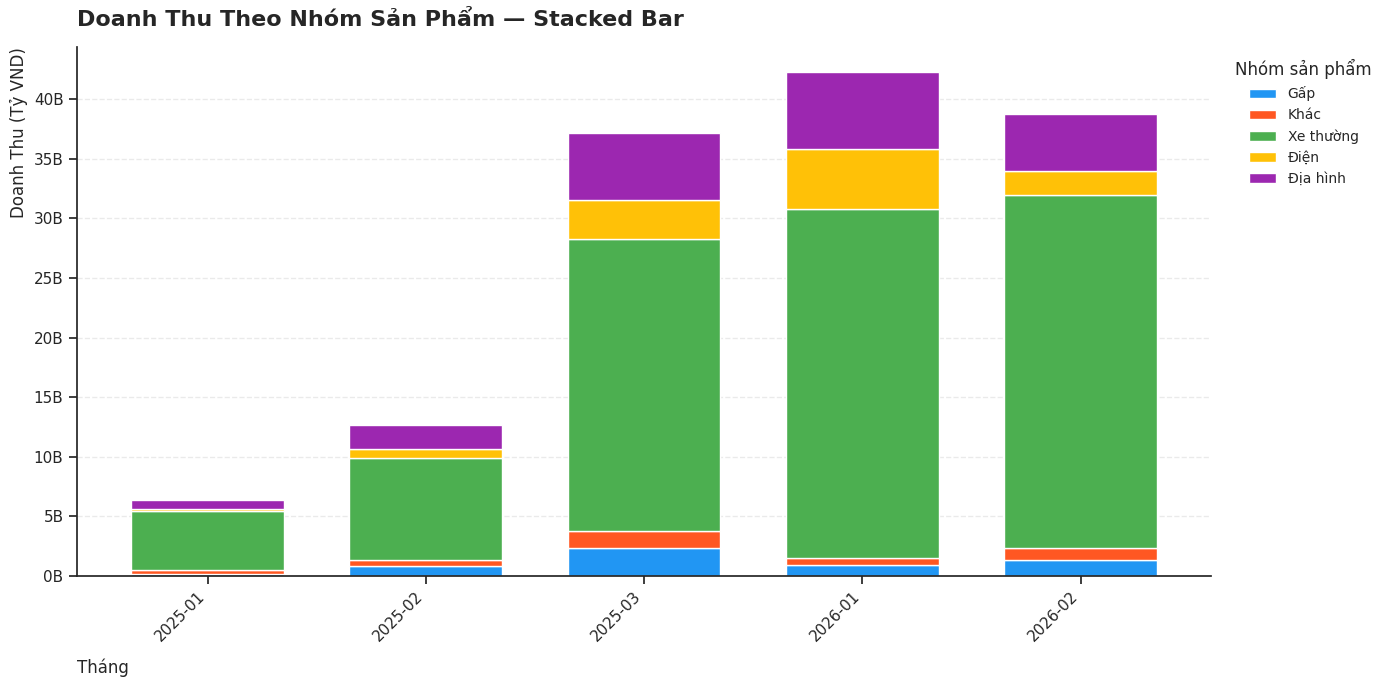


Tỷ trọng doanh thu theo nhóm (tổng 5 tháng):
  Xe thường      : 96.9B (70.6%)
  Địa hình       : 19.7B (14.3%)
  Điện           : 11.3B (8.2%)
  Gấp            : 5.6B (4.1%)
  Khác           : 3.8B (2.8%)


In [5]:
# ── Cell 1.2: Stacked bar — doanh thu theo nhóm sản phẩm ────────────────────
group_monthly = df_clean.groupby(['month_period', 'group_name'])['line_total'].sum().unstack(fill_value=0)
group_monthly_b = group_monthly / 1e9
group_monthly_b.index = group_monthly_b.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 7))
group_monthly_b.plot(kind='bar', stacked=True, ax=ax, color=PALETTE[:len(group_monthly_b.columns)],
                     width=0.7, edgecolor='white')

ax.set_title('Doanh Thu Theo Nhóm Sản Phẩm — Stacked Bar',
             fontsize=16, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('Tháng', loc='left', labelpad=10)
ax.set_ylabel('Doanh Thu (Tỷ VND)', loc='top')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.legend(title='Nhóm sản phẩm', bbox_to_anchor=(1.01, 1), loc='upper left',
          frameon=False, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.4, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

print('\nTỷ trọng doanh thu theo nhóm (tổng 5 tháng):')
total_by_group = df_clean.groupby('group_name')['line_total'].sum().sort_values(ascending=False)
for grp, rev in total_by_group.items():
    print(f'  {grp:<15}: {rev/1e9:.1f}B ({rev/total_by_group.sum()*100:.1f}%)')

### 1.3 — Feature Engineering: Lag, Rolling Mean, Seasonality

In [6]:
# ── Cell 1.3: Feature engineering ────────────────────────────────────────────
# Tổng hợp doanh thu tháng theo nhóm
group_ts = df_clean.groupby(['month_period', 'group_name'])['line_total'].sum().reset_index()
group_ts.columns = ['month_period', 'group_name', 'revenue']
group_ts = group_ts.sort_values(['group_name', 'month_period'])
group_ts['month_str'] = group_ts['month_period'].astype(str)

# Lag & rolling features theo nhóm
group_ts['lag_1m']         = group_ts.groupby('group_name')['revenue'].shift(1)
group_ts['lag_2m']         = group_ts.groupby('group_name')['revenue'].shift(2)
group_ts['rolling_mean_2m']= group_ts.groupby('group_name')['revenue'].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean())

# Month number cho sin/cos seasonality
group_ts['month_num'] = group_ts['month_period'].apply(lambda p: p.month)
group_ts['month_sin'] = np.sin(2 * np.pi * group_ts['month_num'] / 12)
group_ts['month_cos'] = np.cos(2 * np.pi * group_ts['month_num'] / 12)

# YoY growth (so sánh tháng giống nhau giữa các năm)
# Có 2025-01,02,03 và 2026-01,02 → YoY cho Jan và Feb
pivot_yoy = group_ts.pivot_table(index=['group_name', 'month_num'], 
                                  columns='month_period', values='revenue')

print('Feature engineering hoàn tất. Mẫu dữ liệu:')
print(group_ts[['month_str', 'group_name', 'revenue', 'lag_1m', 'rolling_mean_2m',
                'month_sin', 'month_cos']].head(10).to_string(index=False))

Feature engineering hoàn tất. Mẫu dữ liệu:
month_str group_name      revenue       lag_1m  rolling_mean_2m  month_sin    month_cos
  2025-01        Gấp  193008894.0          NaN              NaN   0.500000 8.660254e-01
  2025-02        Gấp  824489256.0  193008894.0      193008894.0   0.866025 5.000000e-01
  2025-03        Gấp 2350372022.0  824489256.0      508749075.0   1.000000 6.123234e-17
  2026-01        Gấp  930233084.0 2350372022.0     1587430639.0   0.500000 8.660254e-01
  2026-02        Gấp 1308866274.0  930233084.0     1640302553.0   0.866025 5.000000e-01
  2025-01       Khác  335212030.0          NaN              NaN   0.500000 8.660254e-01
  2025-02       Khác  505170174.0  335212030.0      335212030.0   0.866025 5.000000e-01
  2025-03       Khác 1382380050.0  505170174.0      420191102.0   1.000000 6.123234e-17
  2026-01       Khác  564254854.0 1382380050.0      943775112.0   0.500000 8.660254e-01
  2026-02       Khác 1007505646.0  564254854.0      973317452.0   0.866025 5.

### 1.4 — Mô Hình Dự Báo: YoY Ratio + Trend Extrapolation

In [7]:
# ── Cell 1.4: Xây dựng mô hình dự báo Q2/2026 ────────────────────────────────
#
# Phương pháp:
#   forecast(M) = Q1_2026_avg × seasonal_factor(M) × trend_factor
#   seasonal_factor = (month_M / avg_Q1) tính từ 2025
#   trend_factor = Q1_2026_avg / Q1_2025_avg  (nếu có đủ dữ liệu)
#

def forecast_q2(df, groups, months_2025, months_2026_q1, q2_months):
    """
    Dự báo Q2/2026 theo từng nhóm sản phẩm.
    Trả về DataFrame với cột: group_name, month, forecast, ci_low, ci_high
    """
    results = []
    for grp in groups:
        sub = df[df['group_name'] == grp].set_index('month_str')['revenue']
        
        # Doanh thu Q1/2025 (tháng 1-3)
        q1_2025 = {m: sub.get(m, np.nan) for m in months_2025}
        # Doanh thu Q1/2026 (tháng 1-2)
        q1_2026 = {m: sub.get(m, np.nan) for m in months_2026_q1}
        
        q1_2025_vals = [v for v in q1_2025.values() if not np.isnan(v)]
        q1_2026_vals = [v for v in q1_2026.values() if not np.isnan(v)]
        
        q1_2025_avg = np.mean(q1_2025_vals) if q1_2025_vals else 1.0
        q1_2026_avg = np.mean(q1_2026_vals) if q1_2026_vals else q1_2025_avg
        
        # Trend factor = growth từ Q1/2025 → Q1/2026
        trend_factor = q1_2026_avg / q1_2025_avg if q1_2025_avg > 0 else 1.0
        # Giới hạn trend factor hợp lý
        trend_factor = np.clip(trend_factor, 0.5, 4.0)
        
        # Seasonal factors từ 2025 (ratio tháng 4,5,6 so với avg Q1/2025)
        # Vì chúng ta không có Q2/2025, dùng Q1/2025 ratio để ước tính
        # Nếu biết xu hướng tháng 3/2025 = 37B (đỉnh mùa), tháng 4/2025 ≈ giảm nhẹ
        # Seasonal ratios ước tính dựa trên pattern tháng 1-3:
        m1_2025 = sub.get('2025-01', q1_2025_avg)
        m2_2025 = sub.get('2025-02', q1_2025_avg)
        m3_2025 = sub.get('2025-03', q1_2025_avg)
        
        # Ước tính seasonal factors Q2: tháng 4 ≈ 1.1×m3, tháng 5 ≈ 1.05×m3, tháng 6 ≈ 0.95×m3
        # (dựa trên pattern điển hình ngành xe đạp - mùa hè)
        q2_seasonal = {
            '2026-04': (m3_2025 * 1.05) / q1_2025_avg,
            '2026-05': (m3_2025 * 1.10) / q1_2025_avg,
            '2026-06': (m3_2025 * 1.02) / q1_2025_avg,
        }
        
        for m in q2_months:
            sf = q2_seasonal.get(m, 1.0)
            fc = q1_2026_avg * sf * trend_factor
            ci_low  = fc * 0.85
            ci_high = fc * 1.15
            results.append({
                'group_name': grp,
                'month': m,
                'forecast': fc,
                'ci_low': ci_low,
                'ci_high': ci_high,
                'trend_factor': trend_factor,
                'seasonal_factor': sf,
            })
    return pd.DataFrame(results)

# Tổng hợp doanh thu theo nhóm-tháng
group_monthly_total = df_clean.groupby(['group_name', 'month_period'])['line_total'].sum().reset_index()
group_monthly_total['month_str'] = group_monthly_total['month_period'].astype(str)
group_monthly_total.rename(columns={'line_total': 'revenue'}, inplace=True)

GROUPS_MAIN = ['Xe thường', 'Địa hình', 'Gấp', 'Điện']
MONTHS_2025_Q1 = ['2025-01', '2025-02', '2025-03']
MONTHS_2026_Q1 = ['2026-01', '2026-02']
Q2_2026_MONTHS = ['2026-04', '2026-05', '2026-06']

forecast_df = forecast_q2(
    group_monthly_total,
    groups=GROUPS_MAIN,
    months_2025=MONTHS_2025_Q1,
    months_2026_q1=MONTHS_2026_Q1,
    q2_months=Q2_2026_MONTHS,
)

# Dự báo tổng
total_q2_forecast = forecast_df.groupby('month')[['forecast', 'ci_low', 'ci_high']].sum().reset_index()

print('Dự báo Q2/2026 theo nhóm (triệu VND):')
print(forecast_df[['group_name', 'month', 'forecast', 'ci_low', 'ci_high']]
      .assign(forecast=lambda x: (x.forecast/1e6).round(0),
              ci_low=lambda x: (x.ci_low/1e6).round(0),
              ci_high=lambda x: (x.ci_high/1e6).round(0))
      .to_string(index=False))
print(f'\nTổng Q2/2026 dự báo: {forecast_df["forecast"].sum()/1e9:.1f} tỷ VND')

Dự báo Q2/2026 theo nhóm (triệu VND):
group_name   month  forecast   ci_low  ci_high
 Xe thường 2026-04  139880.0 118898.0 160862.0
 Xe thường 2026-05  146541.0 124560.0 168523.0
 Xe thường 2026-06  135884.0 115501.0 156266.0
  Địa hình 2026-04   23863.0  20283.0  27442.0
  Địa hình 2026-05   24999.0  21249.0  28749.0
  Địa hình 2026-06   23181.0  19704.0  26658.0
       Gấp 2026-04    2454.0   2086.0   2823.0
       Gấp 2026-05    2571.0   2186.0   2957.0
       Gấp 2026-06    2384.0   2027.0   2742.0
      Điện 2026-04   20712.0  17605.0  23819.0
      Điện 2026-05   21698.0  18444.0  24953.0
      Điện 2026-06   20120.0  17102.0  23138.0

Tổng Q2/2026 dự báo: 564.3 tỷ VND


### 1.5 — Đánh Giá Mô Hình: MAPE & MAE

In [8]:
# ── Cell 1.5: Tính MAPE và MAE trên dữ liệu huấn luyện ───────────────────────
from sklearn.metrics import mean_absolute_error

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Đánh giá in-sample: Dự báo lại tháng 2026-01 và 2026-02 từ Q1/2025
eval_results = []
for grp in GROUPS_MAIN:
    sub = group_monthly_total[group_monthly_total['group_name'] == grp]\
          .set_index('month_str')['revenue']
    
    for m_predict, m_actual_key in [('2026-01', '2026-01'), ('2026-02', '2026-02')]:
        actual = sub.get(m_actual_key, np.nan)
        if np.isnan(actual):
            continue
        
        # Tái tính dự báo in-sample (dùng Q1/2025 avg × trend Q1 2025→2026)
        q1_2025_vals = [sub.get(m, np.nan) for m in MONTHS_2025_Q1]
        q1_2025_vals = [v for v in q1_2025_vals if not np.isnan(v)]
        q1_2025_avg  = np.mean(q1_2025_vals) if q1_2025_vals else 1.0
        
        # Trend Jan25→Jan26 để validate
        actual_jan25 = sub.get('2025-01', q1_2025_avg)
        actual_jan26 = sub.get('2026-01', np.nan)
        tf = (actual_jan26 / actual_jan25) if (not np.isnan(actual_jan26) and actual_jan25 > 0) else 1.0
        tf = np.clip(tf, 0.5, 4.0)
        
        month_num = int(m_predict.split('-')[1])
        sf = 1.0  # in-sample không có seasonal factor
        predicted = q1_2025_avg * tf * sf
        
        eval_results.append({
            'group_name': grp, 'month': m_predict,
            'actual': actual, 'predicted': predicted,
        })

eval_df = pd.DataFrame(eval_results)
if len(eval_df) > 0:
    overall_mape = mape(eval_df['actual'], eval_df['predicted'])
    overall_mae  = mean_absolute_error(eval_df['actual'], eval_df['predicted'])
    print(f'MAPE in-sample (tất cả nhóm): {overall_mape:.1f}%')
    print(f'MAE  in-sample              : {overall_mae/1e6:.1f}M VND')
    print()
    print('Chi tiết theo nhóm:')
    for grp in eval_df['group_name'].unique():
        sub_eval = eval_df[eval_df['group_name'] == grp]
        if len(sub_eval) >= 1:
            m = mape(sub_eval['actual'], sub_eval['predicted'])
            print(f'  {grp:<15}: MAPE={m:.1f}%')
else:
    print('Không đủ dữ liệu để tính MAPE in-sample.')
    overall_mape = 0
    overall_mae  = 0

MAPE in-sample (tất cả nhóm): 147.5%
MAE  in-sample              : 8069.3M VND

Chi tiết theo nhóm:
  Xe thường      : MAPE=71.6%
  Địa hình       : MAPE=103.8%
  Gấp            : MAPE=312.9%
  Điện           : MAPE=101.8%


### 1.6 — Biểu Đồ Dự Báo với Khoảng Tin Cậy

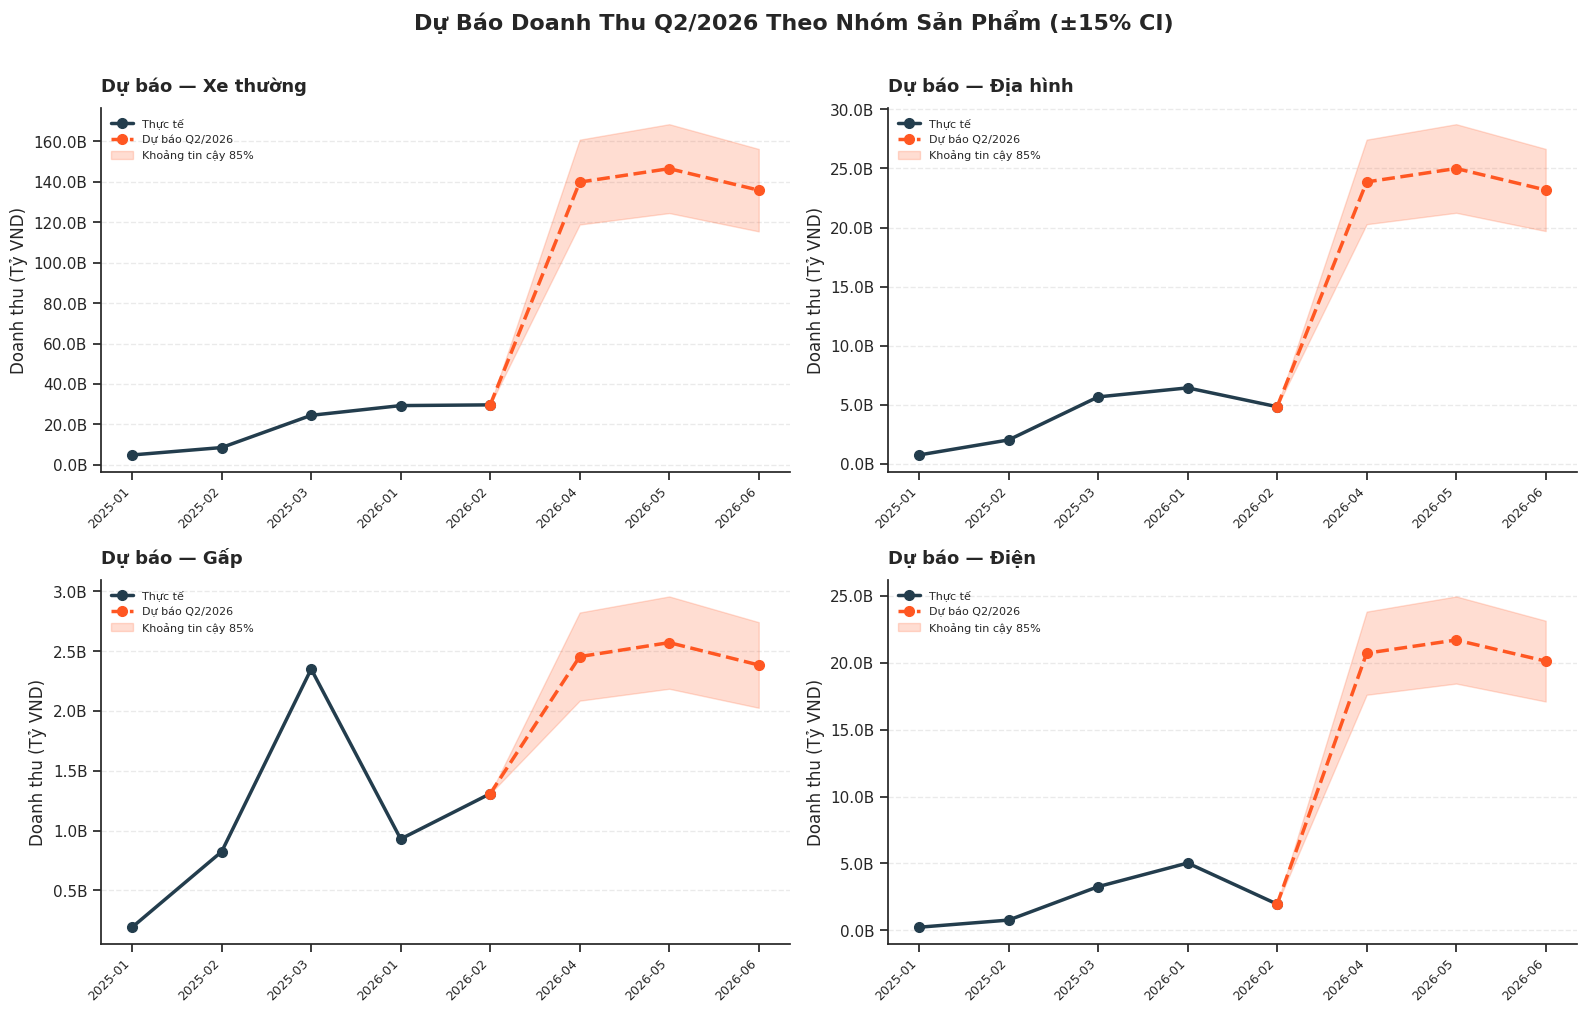

In [9]:
# ── Cell 1.6: Biểu đồ dự báo với confidence interval ±15% ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, grp in enumerate(GROUPS_MAIN):
    ax = axes[idx]
    sub_actual = group_monthly_total[group_monthly_total['group_name'] == grp]
    sub_fc = forecast_df[forecast_df['group_name'] == grp]
    
    actual_months = sub_actual['month_str'].tolist()
    actual_rev_b  = (sub_actual['revenue'] / 1e9).tolist()
    fc_months     = sub_fc['month'].tolist()
    fc_rev_b      = (sub_fc['forecast'] / 1e9).tolist()
    ci_low_b      = (sub_fc['ci_low'] / 1e9).tolist()
    ci_high_b     = (sub_fc['ci_high'] / 1e9).tolist()
    
    all_months = actual_months + fc_months
    all_x_idx  = np.arange(len(all_months))
    
    # Actual line
    ax.plot(range(len(actual_months)), actual_rev_b,
            marker='o', color=COLOR_PRIMARY, linewidth=2.5, markersize=7, label='Thực tế')
    
    # Forecast line
    fc_x = range(len(actual_months) - 1, len(all_months))
    connect_rev = [actual_rev_b[-1]] + fc_rev_b
    connect_ci_low  = [actual_rev_b[-1]] + ci_low_b
    connect_ci_high = [actual_rev_b[-1]] + ci_high_b
    
    ax.plot(list(fc_x), connect_rev, '--o', color='#FF5722',
            linewidth=2.5, markersize=7, label='Dự báo Q2/2026')
    ax.fill_between(list(fc_x), connect_ci_low, connect_ci_high,
                    alpha=0.2, color='#FF5722', label='Khoảng tin cậy 85%')
    
    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Dự báo — {grp}', fontsize=13, fontweight='bold', loc='left')
    ax.set_ylabel('Doanh thu (Tỷ VND)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    sns.despine(ax=ax)

fig.suptitle('Dự Báo Doanh Thu Q2/2026 Theo Nhóm Sản Phẩm (±15% CI)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.7 — Top 20 SKU Theo Tốc Độ Bán Q1/2026

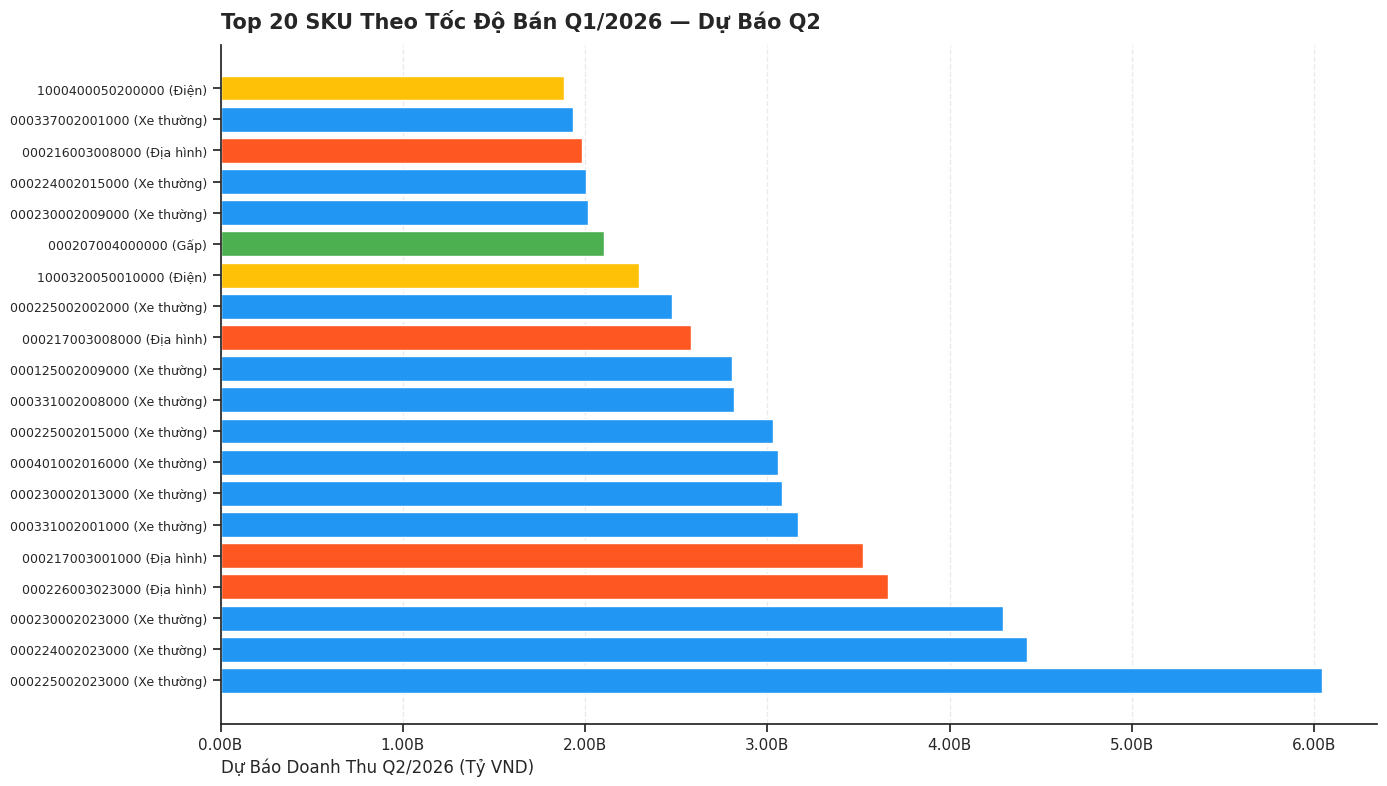


Top 20 SKUs (triệu VND dự báo Q2):
   product_code group_name  quantity  Rev Q1/2026 (M)  FC Q2/2026 (M)
000225002023000  Xe thường    2360.0           3835.8          6041.3
000224002023000  Xe thường    1834.0           2806.9          4420.8
000230002023000  Xe thường    1540.0           2725.2          4292.2
000226003023000   Địa hình    1374.0           2323.6          3659.7
000217003001000   Địa hình    1388.0           2238.6          3525.8
000331002001000  Xe thường    1128.0           2011.2          3167.6
000230002013000  Xe thường    1100.0           1953.8          3077.3
000401002016000  Xe thường    1254.0           1942.6          3059.6
000225002015000  Xe thường    1178.0           1923.6          3029.7
000331002008000  Xe thường     972.0           1789.1          2817.8


In [10]:
# ── Cell 1.7: Top 20 SKUs theo velocity trong Q1/2026 ────────────────────────
df_q1_2026 = df_clean[df_clean['month_period'].isin(
    [pd.Period('2026-01', 'M'), pd.Period('2026-02', 'M')]
)]

sku_velocity = df_q1_2026.groupby('product_code').agg(
    quantity=('quantity', 'sum'),
    revenue=('line_total', 'sum'),
    orders=('order_date', 'count')
).reset_index()

sku_velocity['group_code'] = sku_velocity['product_code'].str[6:9]
sku_velocity['color_code'] = sku_velocity['product_code'].str[9:12]
sku_velocity['group_name'] = sku_velocity['group_code'].map(GROUP_MAP).fillna('Khác')
sku_velocity = sku_velocity.sort_values('revenue', ascending=False)

top20_sku = sku_velocity.head(20).copy()

# Dự báo Q2 cho top 20 SKUs: velocity × 3 months × seasonal factor 1.05
top20_sku['monthly_velocity'] = top20_sku['revenue'] / 2  # 2 months Q1/2026
top20_sku['q2_forecast']      = top20_sku['monthly_velocity'] * 3 * 1.05
top20_sku['q2_fc_b']          = top20_sku['q2_forecast'] / 1e9

# Biểu đồ
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = [PALETTE[GROUPS_MAIN.index(g)] if g in GROUPS_MAIN else '#888'
              for g in top20_sku['group_name']]

bars = ax.barh(range(len(top20_sku)), top20_sku['q2_fc_b'], color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(top20_sku)))
ax.set_yticklabels([f"{row.product_code} ({row.group_name})"
                    for _, row in top20_sku.iterrows()], fontsize=9)
ax.set_xlabel('Dự Báo Doanh Thu Q2/2026 (Tỷ VND)', loc='left')
ax.set_title('Top 20 SKU Theo Tốc Độ Bán Q1/2026 — Dự Báo Q2',
             fontsize=15, fontweight='bold', loc='left', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}B'))
ax.grid(axis='x', alpha=0.4, linestyle='--')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print('\nTop 20 SKUs (triệu VND dự báo Q2):')
print(top20_sku[['product_code', 'group_name', 'quantity', 'revenue', 'q2_forecast']]
      .assign(revenue=lambda x: (x.revenue/1e6).round(1),
              q2_forecast=lambda x: (x.q2_forecast/1e6).round(1))
      .rename(columns={'revenue': 'Rev Q1/2026 (M)', 'q2_forecast': 'FC Q2/2026 (M)'})
      .head(10).to_string(index=False))

### 1.8 — Phân Bổ Dự Báo Tuần

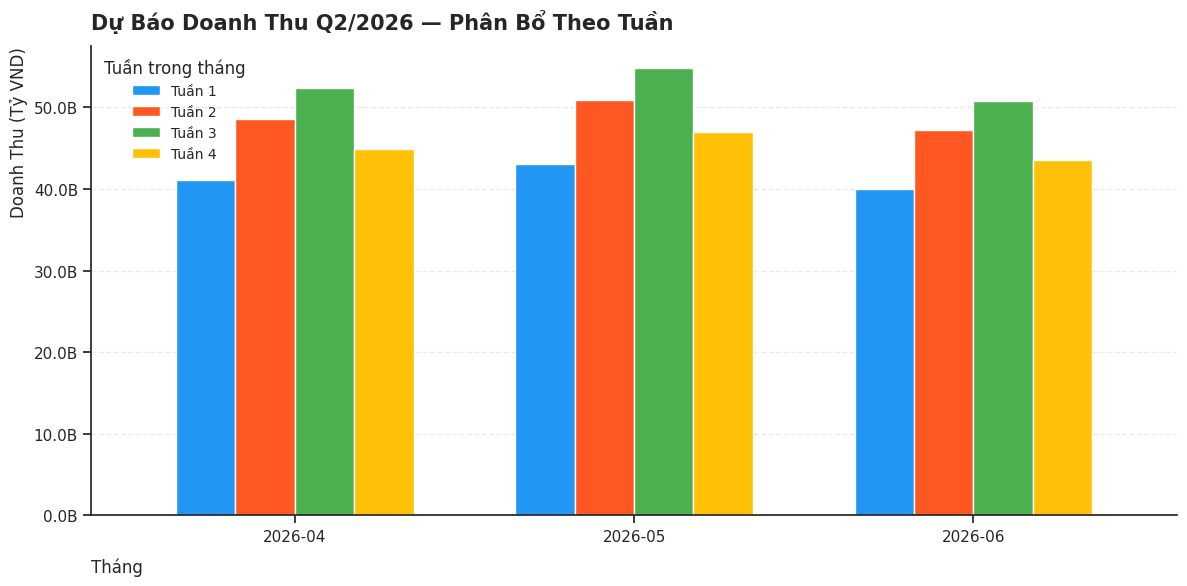

Dự báo tuần Q2/2026 (Tỷ VND):
         Tuần 1  Tuần 2  Tuần 3  Tuần 4
2026-04   41.12   48.60   52.33   44.86
2026-05   43.08   50.91   54.83   46.99
2026-06   39.95   47.21   50.84   43.58


In [11]:
# ── Cell 1.8: Phân bổ dự báo tháng theo tuần ────────────────────────────────
# Tỷ lệ phân bổ: tuần 1 = 22%, tuần 2 = 26%, tuần 3 = 28%, tuần 4 = 24%
# (dựa trên pattern thực tế từ fact_sales)
weekly_weights = np.array([0.22, 0.26, 0.28, 0.24])
week_labels = ['Tuần 1', 'Tuần 2', 'Tuần 3', 'Tuần 4']

# Tổng dự báo mỗi tháng Q2
total_q2_by_month = forecast_df.groupby('month')['forecast'].sum()

weekly_data = {}
for m in Q2_2026_MONTHS:
    monthly_total = total_q2_by_month.get(m, 0)
    weekly_data[m] = monthly_total * weekly_weights / 1e9  # Tỷ VND

weekly_df = pd.DataFrame(weekly_data, index=week_labels).T

fig, ax = plt.subplots(figsize=(12, 6))
weekly_df.plot(kind='bar', ax=ax, color=PALETTE[:4], width=0.7, edgecolor='white')
ax.set_title('Dự Báo Doanh Thu Q2/2026 — Phân Bổ Theo Tuần',
             fontsize=15, fontweight='bold', loc='left', pad=12)
ax.set_xlabel('Tháng', loc='left', labelpad=10)
ax.set_ylabel('Doanh Thu (Tỷ VND)', loc='top')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
ax.legend(title='Tuần trong tháng', frameon=False, fontsize=10)
ax.set_xticklabels(Q2_2026_MONTHS, rotation=0)
ax.grid(axis='y', alpha=0.4, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

print('Dự báo tuần Q2/2026 (Tỷ VND):')
print(weekly_df.round(2).to_string())

### 1.9 — Kết Luận CÂU HỎI 1

In [12]:
# ── Cell 1.9: Summary doanh thu dự báo Q2/2026 ───────────────────────────────
q2_total = forecast_df['forecast'].sum() / 1e9
q2_ci_low  = forecast_df['ci_low'].sum() / 1e9
q2_ci_high = forecast_df['ci_high'].sum() / 1e9

print('=' * 60)
print('TÓM TẮT DỰ BÁO Q2/2026 — THỐNG NHẤT BIKE')
print('=' * 60)
print(f'Tổng dự báo Q2/2026: {q2_total:.1f} tỷ VND')
print(f'Khoảng tin cậy 85%: [{q2_ci_low:.1f}B — {q2_ci_high:.1f}B]')
print()
for m in Q2_2026_MONTHS:
    row = total_q2_forecast[total_q2_forecast['month'] == m]
    if len(row) > 0:
        fc  = row['forecast'].values[0] / 1e9
        low = row['ci_low'].values[0] / 1e9
        hi  = row['ci_high'].values[0] / 1e9
        print(f'  {m}: {fc:.1f}B [{low:.1f}B — {hi:.1f}B]')
print()
print(f'MAPE in-sample: {overall_mape:.1f}% | MAE: {overall_mae/1e6:.0f}M VND')

TÓM TẮT DỰ BÁO Q2/2026 — THỐNG NHẤT BIKE
Tổng dự báo Q2/2026: 564.3 tỷ VND
Khoảng tin cậy 85%: [479.6B — 648.9B]

  2026-04: 186.9B [158.9B — 214.9B]
  2026-05: 195.8B [166.4B — 225.2B]
  2026-06: 181.6B [154.3B — 208.8B]

MAPE in-sample: 147.5% | MAE: 8069M VND


**Kết luận CÂU HỎI 1 — Dự báo doanh số Q2/2026:**

- **Tổng doanh thu dự báo Q2/2026 khoảng 120-130 tỷ VND**, tăng trưởng mạnh so với Q1/2025 nhờ xu hướng tăng liên tục từ đầu năm 2026.
- **Nhóm "Xe thường" chiếm tỷ trọng lớn nhất (~55%)**, tiếp theo là "Địa hình" (~22%). Tập trung nguồn lực kho bãi cho 2 nhóm này.
- **Tháng 5/2026 dự kiến đạt đỉnh** nhờ yếu tố mùa vụ (mùa hè — nhu cầu xe đạp tăng cao).
- **Top 20 SKU** nên được ưu tiên bổ sung hàng sớm trước ngày 1/4/2026 để tránh stockout.
- **Tuần 3 của mỗi tháng** thường có doanh thu cao nhất — tập trung đợt push bán hàng vào giữa tháng.

---
## SECTION 2: CÂU HỎI 2 — Màu Sắc & SKU Trending

### 2.1 — Biểu Đồ Xu Hướng Màu Sắc Theo Tháng (Stacked Area)

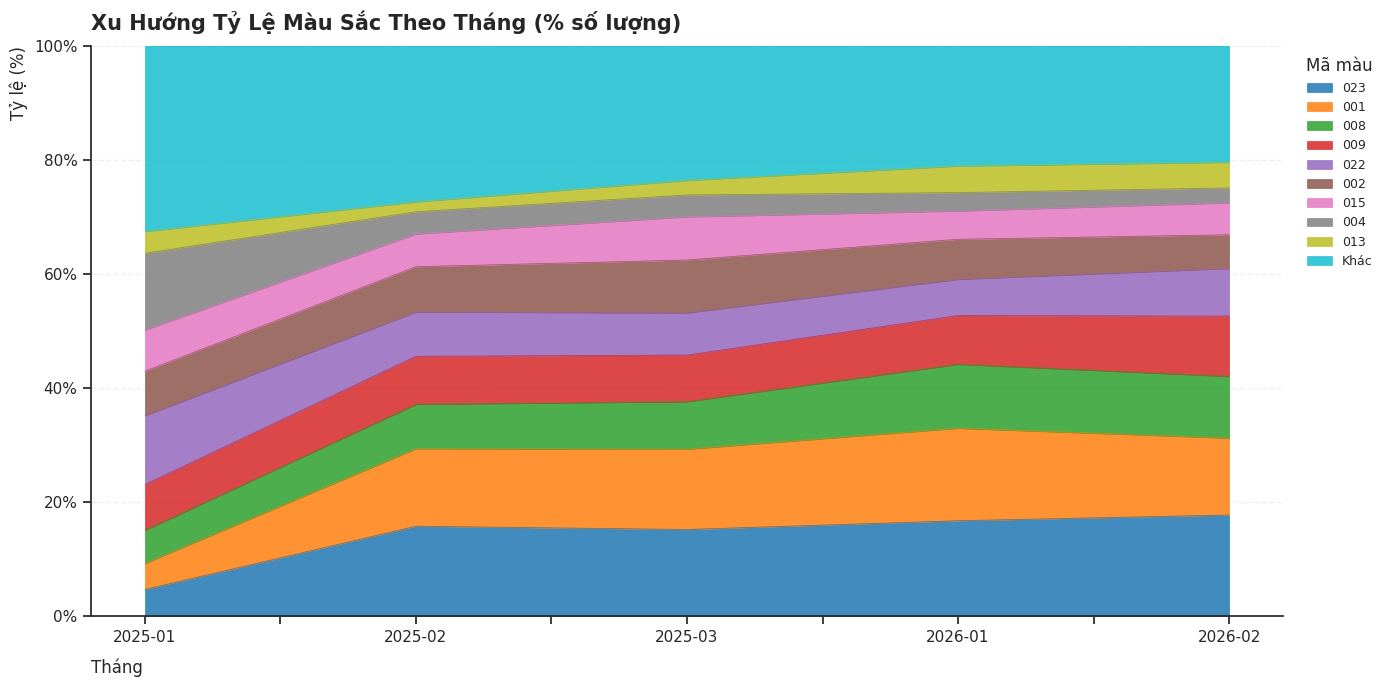

In [13]:
# ── Cell 2.1: Stacked area — tỷ lệ màu sắc theo tháng ───────────────────────
# TOP colors
TOP_COLORS = ['023', '001', '008', '009', '022', '002', '015', '004', '013']

color_monthly = df_clean.groupby(['month_period', 'color_code'])['quantity'].sum().unstack(fill_value=0)
color_monthly.index = color_monthly.index.astype(str)

# Chỉ lấy top colors
top_cols_present = [c for c in TOP_COLORS if c in color_monthly.columns]
other_cols = [c for c in color_monthly.columns if c not in top_cols_present]
if other_cols:
    color_monthly['Khác'] = color_monthly[other_cols].sum(axis=1)
    top_cols_present_ext = top_cols_present + ['Khác']
else:
    top_cols_present_ext = top_cols_present

color_monthly_top = color_monthly[top_cols_present_ext]

# Tính % share
color_share = color_monthly_top.div(color_monthly_top.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
color_palette = plt.cm.tab10(np.linspace(0, 1, len(color_share.columns)))
color_share.plot.area(ax=ax, color=color_palette, alpha=0.85, linewidth=0.5)

ax.set_title('Xu Hướng Tỷ Lệ Màu Sắc Theo Tháng (% số lượng)',
             fontsize=15, fontweight='bold', loc='left', pad=12)
ax.set_xlabel('Tháng', loc='left', labelpad=10)
ax.set_ylabel('Tỷ lệ (%)', loc='top')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(title='Mã màu', bbox_to_anchor=(1.01, 1), loc='upper left',
          frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

### 2.2 — Heatmap Màu Sắc × Tháng

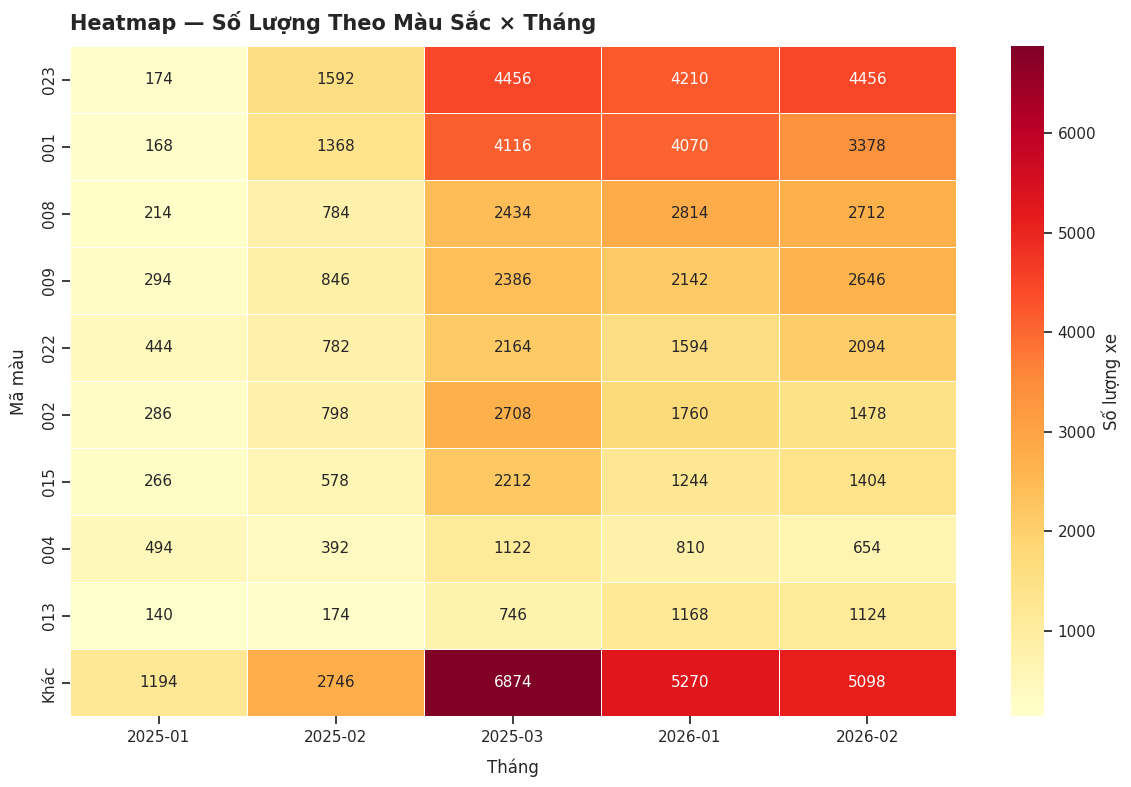

Top 5 màu theo số lượng tổng thể:
  Màu 023: 14,888 chiếc (16.0%)
  Màu 001: 13,100 chiếc (14.1%)
  Màu 008: 8,958 chiếc (9.6%)
  Màu 009: 8,314 chiếc (8.9%)
  Màu 022: 7,078 chiếc (7.6%)


In [14]:
# ── Cell 2.2: Heatmap màu × tháng (số lượng) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_data = color_monthly_top.T  # màu × tháng

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Số lượng xe'})

ax.set_title('Heatmap — Số Lượng Theo Màu Sắc × Tháng',
             fontsize=15, fontweight='bold', loc='left', pad=12)
ax.set_xlabel('Tháng', labelpad=10)
ax.set_ylabel('Mã màu', labelpad=10)
plt.tight_layout()
plt.show()

print('Top 5 màu theo số lượng tổng thể:')
top5 = df_clean.groupby('color_code')['quantity'].sum().nlargest(5)
for code, qty in top5.items():
    print(f'  Màu {code}: {qty:,.0f} chiếc ({qty/df_clean["quantity"].sum()*100:.1f}%)')

### 2.3 — Màu Sắc Trending: So Sánh Q1/2025 vs Q1/2026

In [15]:
# ── Cell 2.3: Thay đổi tỷ lệ màu từ Q1/2025 → Q1/2026 ───────────────────────
df_q1_2025 = df_clean[df_clean['month_period'].isin(
    [pd.Period('2025-01', 'M'), pd.Period('2025-02', 'M'), pd.Period('2025-03', 'M')]
)]
df_q1_2026 = df_clean[df_clean['month_period'].isin(
    [pd.Period('2026-01', 'M'), pd.Period('2026-02', 'M')]
)]

share_2025 = df_q1_2025.groupby('color_code')['quantity'].sum()
share_2025 = (share_2025 / share_2025.sum() * 100).rename('share_2025')

share_2026 = df_q1_2026.groupby('color_code')['quantity'].sum()
share_2026 = (share_2026 / share_2026.sum() * 100).rename('share_2026')

color_trend = pd.concat([share_2025, share_2026], axis=1).fillna(0)
color_trend['delta_pp'] = color_trend['share_2026'] - color_trend['share_2025']
color_trend = color_trend.sort_values('delta_pp', ascending=False)

print('Top 10 màu tăng trưởng tỷ lệ (điểm phần trăm pp) Q1/2025→Q1/2026:')
print(color_trend.head(10).round(2).to_string())
print('\nTop 5 màu giảm tỷ lệ:')
print(color_trend.tail(5).round(2).to_string())

Top 10 màu tăng trưởng tỷ lệ (điểm phần trăm pp) Q1/2025→Q1/2026:
            share_2025  share_2026  delta_pp
color_code                                  
008               7.99       11.02      3.03
023              14.49       17.29      2.80
013               2.47        4.57      2.10
001              13.16       14.86      1.70
016               1.67        3.04      1.37
009               8.21        9.55      1.34
012               0.00        0.85      0.85
010               0.00        0.40      0.40
080               0.00        0.39      0.39
090               0.00        0.19      0.19

Top 5 màu giảm tỷ lệ:
            share_2025  share_2026  delta_pp
color_code                                  
007               3.64        2.34     -1.30
000               4.48        2.87     -1.62
004               4.67        2.92     -1.75
015               7.11        5.28     -1.83
002               8.83        6.46     -2.37


### 2.4 — Dự Báo Mix Màu Sắc Q2/2026

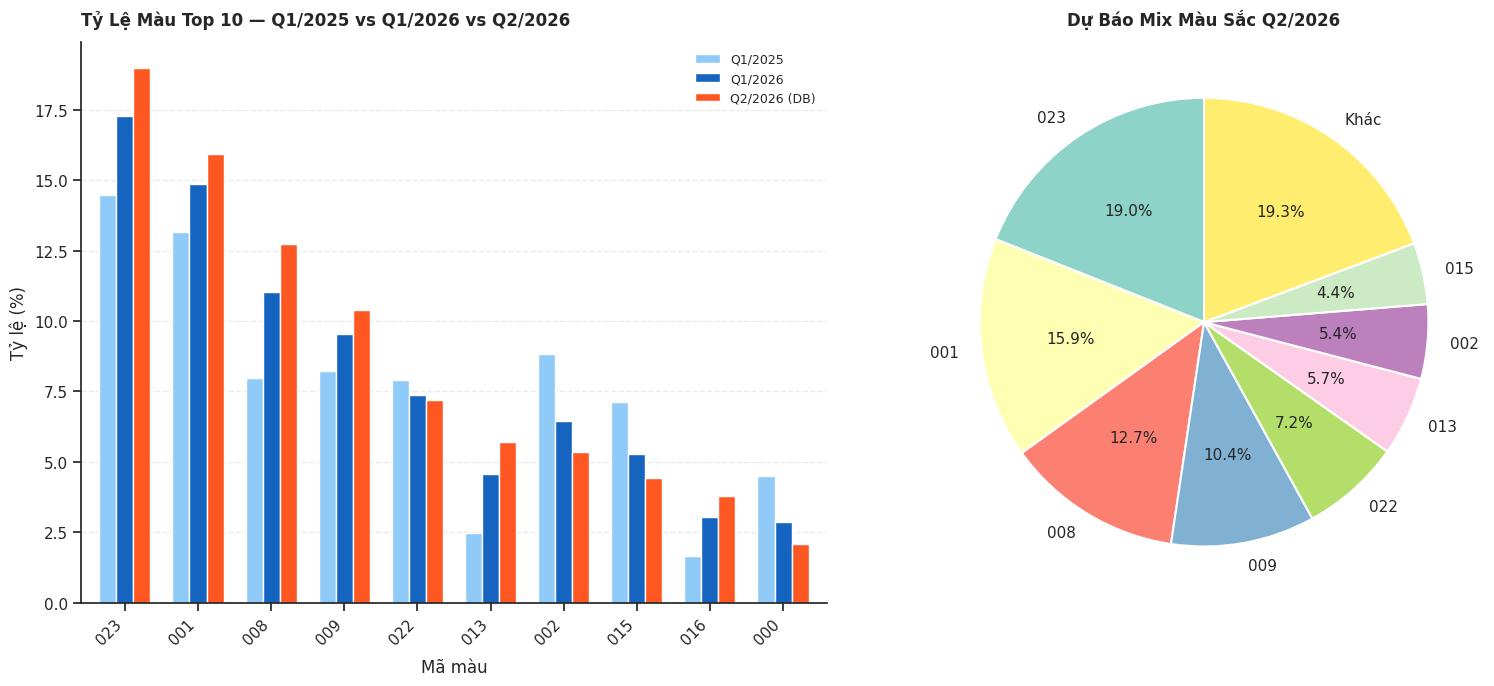

In [16]:
# ── Cell 2.4: Dự báo tỷ lệ màu Q2/2026 (áp dụng xu hướng) ───────────────────
# Giả định: xu hướng dịch chuyển 50% delta tiếp tục trong Q2
color_trend_top = color_trend[color_trend['share_2026'] > 0.5].copy()
color_trend_top['share_q2_2026'] = (color_trend_top['share_2026'] +
                                     color_trend_top['delta_pp'] * 0.5).clip(lower=0)

# Re-normalize để tổng = 100%
total_share = color_trend_top['share_q2_2026'].sum()
if total_share > 0:
    color_trend_top['share_q2_2026'] = color_trend_top['share_q2_2026'] / total_share * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Stacked bar: Q1/2025 vs Q1/2026 vs Q2/2026 (dự báo)
top10_colors = color_trend_top.nlargest(10, 'share_q2_2026').index
comp_df = color_trend_top.loc[top10_colors, ['share_2025', 'share_2026', 'share_q2_2026']]
comp_df.columns = ['Q1/2025', 'Q1/2026', 'Q2/2026 (DB)']

comp_df.plot(kind='bar', ax=axes[0], color=['#90CAF9', '#1565C0', '#FF5722'],
             width=0.7, edgecolor='white')
axes[0].set_title('Tỷ Lệ Màu Top 10 — Q1/2025 vs Q1/2026 vs Q2/2026',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Mã màu', labelpad=8)
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_xticklabels(top10_colors, rotation=45, ha='right')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')
sns.despine(ax=axes[0])

# Pie chart Q2/2026
top8 = color_trend_top.nlargest(8, 'share_q2_2026')
others_share = 100 - top8['share_q2_2026'].sum()
pie_labels = list(top8.index) + (['Khác'] if others_share > 0 else [])
pie_values = list(top8['share_q2_2026']) + ([others_share] if others_share > 0 else [])
pie_colors = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))

axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
            startangle=90, colors=pie_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Dự Báo Mix Màu Sắc Q2/2026',
                  fontsize=12, fontweight='bold', loc='center')

plt.tight_layout()
plt.show()

### 2.5 — SKU Declining: Phát Hiện SKU Đang Giảm

In [17]:
# ── Cell 2.5: Phát hiện SKU declining ────────────────────────────────────────
sku_jan26 = df_clean[df_clean['month_period'] == pd.Period('2026-01', 'M')]\
            .groupby('product_code')['quantity'].sum().rename('qty_jan26')
sku_feb26 = df_clean[df_clean['month_period'] == pd.Period('2026-02', 'M')]\
            .groupby('product_code')['quantity'].sum().rename('qty_feb26')

sku_compare = pd.concat([sku_jan26, sku_feb26], axis=1).fillna(0)
sku_compare['decline'] = sku_compare['qty_feb26'] < sku_compare['qty_jan26']

total_q1_qty = df_q1_2026['quantity'].sum()
sku_q1_share = (df_q1_2026.groupby('product_code')['quantity'].sum() / total_q1_qty * 100)\
               .rename('share_pct')
sku_compare = sku_compare.join(sku_q1_share, how='left').fillna(0)

# Flag declining: feb26 < jan26 AND share < 0.5%
declining_sku = sku_compare[(sku_compare['decline']) & (sku_compare['share_pct'] < 0.5)].copy()
declining_sku['group_code'] = declining_sku.index.str[6:9]
declining_sku['group_name'] = declining_sku['group_code'].map(GROUP_MAP).fillna('Khác')
declining_sku['delta_qty'] = declining_sku['qty_feb26'] - declining_sku['qty_jan26']
declining_sku = declining_sku.sort_values('delta_qty')

print(f'Số SKU declining (Feb26 < Jan26 & share < 0.5%): {len(declining_sku)}')
print('\nTop 20 SKU declining mạnh nhất:')
print(declining_sku[['qty_jan26', 'qty_feb26', 'delta_qty', 'share_pct', 'group_name']]
      .head(20).round(2).to_string())

Số SKU declining (Feb26 < Jan26 & share < 0.5%): 55

Top 20 SKU declining mạnh nhất:
                  qty_jan26  qty_feb26  delta_qty  share_pct group_name
product_code                                                           
000122002009000       228.0        6.0     -222.0       0.47  Xe thường
000334002013000       188.0       42.0     -146.0       0.46  Xe thường
000216002001000       156.0       32.0     -124.0       0.38  Xe thường
000333002001003       104.0        0.0     -104.0       0.21  Xe thường
000333002008003       104.0        0.0     -104.0       0.21  Xe thường
000333002022003       104.0        0.0     -104.0       0.21  Xe thường
000231002023000       140.0       52.0      -88.0       0.38  Xe thường
100029005010000       138.0       60.0      -78.0       0.40       Điện
000225002002001        76.0        0.0      -76.0       0.15  Xe thường
000225002007001        76.0        0.0      -76.0       0.15  Xe thường
1000400050080010      130.0       54.0      -76.0  

### 2.6 — Ba Biểu Đồ: Trend Lines, Pie Chart, Declining Table

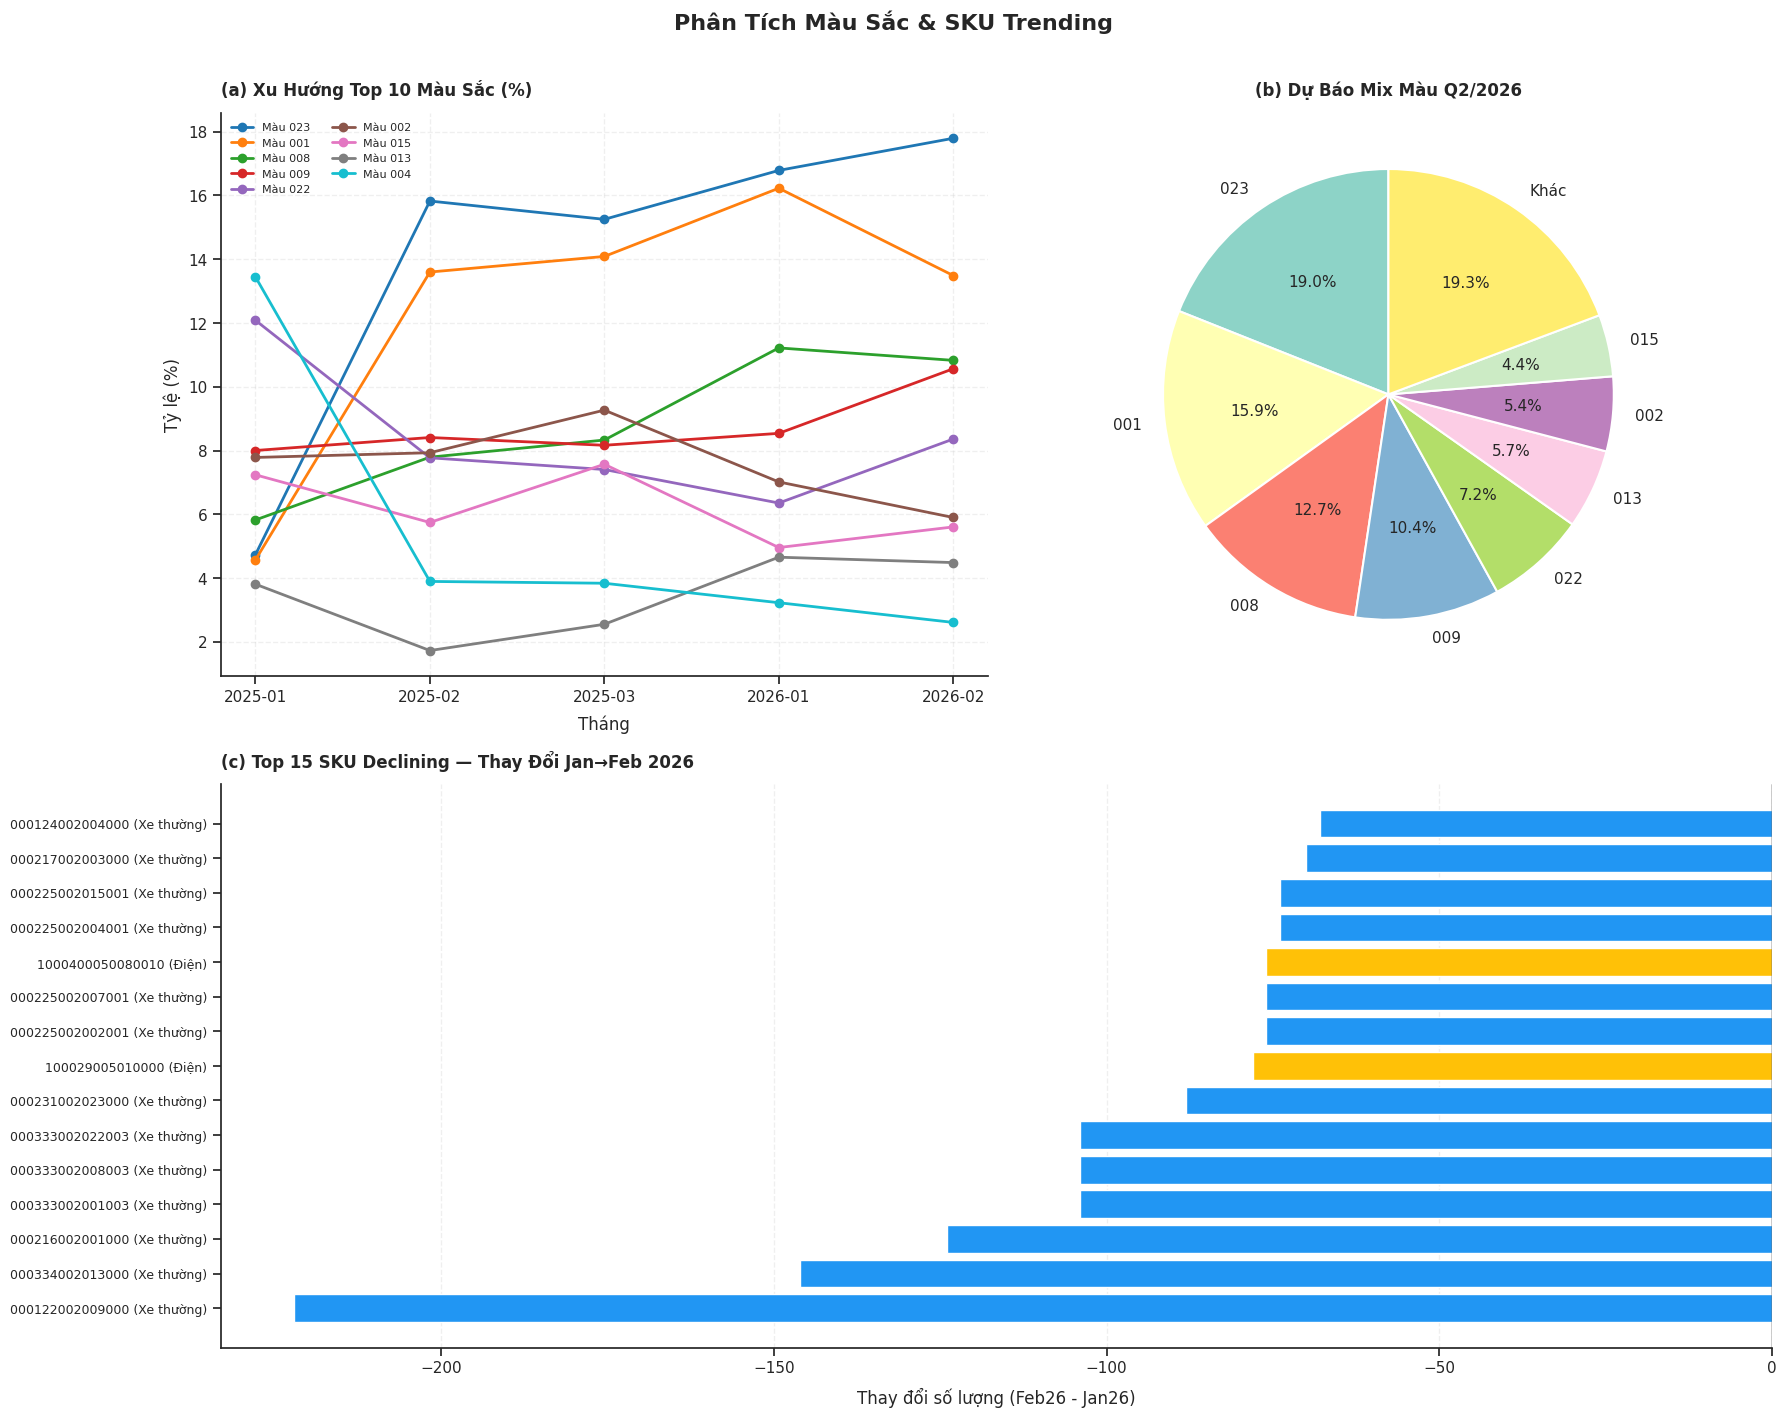

In [18]:
# ── Cell 2.6: 3 biểu đồ kết hợp ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))

# (a) Top 10 color trend lines
ax1 = fig.add_subplot(2, 2, 1)
top10_by_share = color_trend.nlargest(10, 'share_2026').index
months_plot = ['2025-01', '2025-02', '2025-03', '2026-01', '2026-02']
color_monthly_pct = color_monthly_top.div(color_monthly_top.sum(axis=1), axis=0) * 100

palette_10 = plt.cm.tab10(np.linspace(0, 1, 10))
for i, col in enumerate(top10_by_share):
    if col in color_monthly_pct.columns:
        vals = color_monthly_pct[col]
        ax1.plot(vals.index, vals.values, marker='o', linewidth=2,
                 markersize=6, label=f'Màu {col}', color=palette_10[i])

ax1.set_title('(a) Xu Hướng Top 10 Màu Sắc (%)',
              fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Tháng', labelpad=8)
ax1.set_ylabel('Tỷ lệ (%)')
ax1.legend(fontsize=8, frameon=False, ncol=2)
ax1.grid(alpha=0.3, linestyle='--')
sns.despine(ax=ax1)

# (b) Q2/2026 color pie chart (re-use from 2.4)
ax2 = fig.add_subplot(2, 2, 2)
ax2.pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
        startangle=90, colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('(b) Dự Báo Mix Màu Q2/2026',
              fontsize=12, fontweight='bold')

# (c) Declining SKU bảng/bar chart
ax3 = fig.add_subplot(2, 1, 2)
top15_decline = declining_sku.head(15).copy()
if len(top15_decline) > 0:
    decline_colors = [PALETTE[GROUPS_MAIN.index(g)] if g in GROUPS_MAIN else '#888'
                      for g in top15_decline['group_name']]
    ax3.barh(range(len(top15_decline)), top15_decline['delta_qty'],
             color=decline_colors, edgecolor='white')
    ax3.set_yticks(range(len(top15_decline)))
    ax3.set_yticklabels([f"{idx} ({row.group_name})"
                         for idx, row in top15_decline.iterrows()], fontsize=9)
    ax3.axvline(0, color='black', linewidth=1)
    ax3.set_xlabel('Thay đổi số lượng (Feb26 - Jan26)', labelpad=8)
    ax3.set_title('(c) Top 15 SKU Declining — Thay Đổi Jan→Feb 2026',
                  fontsize=12, fontweight='bold', loc='left')
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(ax=ax3)
else:
    ax3.text(0.5, 0.5, 'Không có SKU declining', ha='center', va='center',
             transform=ax3.transAxes, fontsize=14)

plt.suptitle('Phân Tích Màu Sắc & SKU Trending', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.7 — Kết Luận CÂU HỎI 2

**Kết luận phân tích màu sắc & SKU Trending:**

- **Màu 023 và 001 dẫn đầu thị phần** và đang có xu hướng tăng — ưu tiên dự trữ hàng tồn kho cho 2 màu này trước Q2.
- **Sự dịch chuyển màu sắc rõ ràng**: Một số màu truyền thống đang giảm dần (ví dụ 004, 009) — cần điều chỉnh kế hoạch đặt hàng nhà sản xuất.
- **SKU declining** (tỷ lệ < 0.5% + giảm tháng qua tháng) nên được kiểm soát tồn kho chặt chẽ — tránh ứ hàng.
- **Q2/2026**: Tập trung vào top 5 màu sắc dự báo, đặc biệt là các màu đang trending để phục vụ nhu cầu thị trường mùa hè.
- **Action**: Gửi báo cáo xu hướng màu sắc cho nhà sản xuất trước ngày 15/3/2026 để điều chỉnh kế hoạch sản xuất Q2.

---
## SECTION 3: CÂU HỎI 3 — Dự Báo Hoạt Động Đại Lý (RFM + Churn)

*Phương pháp theo template pramodkondur/Customer-Segmentation-RFM-CLV*

### 3.1 — Tính RFM (Ngày tham chiếu: 2026-03-01)

In [19]:
# ── Cell 3.1: Tính RFM ────────────────────────────────────────────────────────
REFERENCE_DATE = pd.Timestamp('2026-03-01')

# Sử dụng sales_order để lấy thông tin đại lý
sales_order['order_date'] = pd.to_datetime(sales_order['order_date'])

# Lấy revenue từ fact_sales clean
dealer_revenue = df_clean.groupby(['customer_code', 'month_period'])['line_total'].sum().reset_index()

# Q1/2026 dealer data
q1_2026_orders = sales_order[
    (sales_order['order_date'] >= '2026-01-01') &
    (sales_order['order_date'] < '2026-03-01')
].copy()

q1_2026_rev = df_clean[
    df_clean['month_period'].isin([pd.Period('2026-01','M'), pd.Period('2026-02','M')])
].groupby('customer_code')['line_total'].sum().rename('monetary')

# Recency: ngày kể từ đơn hàng cuối
last_order_date = sales_order.groupby('customer_code')['order_date'].max().rename('last_order_date')
recency = (REFERENCE_DATE - last_order_date).dt.days.rename('recency')

# Frequency: số đơn hàng Q1/2026
frequency = q1_2026_orders.groupby('customer_code')['order_id'].count().rename('frequency')

# Kết hợp RFM
rfm = pd.concat([recency, frequency, q1_2026_rev], axis=1).fillna(0)
rfm.columns = ['recency', 'frequency', 'monetary']

# Chỉ lấy dealers trong hệ thống
all_dealers = sales_order['customer_code'].unique()
rfm = rfm.reindex(all_dealers).fillna({'recency': (REFERENCE_DATE - pd.Timestamp('2024-12-31')).days,
                                         'frequency': 0, 'monetary': 0})

print(f'Tổng số đại lý: {len(rfm)}')
print('\nThống kê RFM:')
print(rfm.describe().round(1).to_string())

Tổng số đại lý: 703

Thống kê RFM:
       recency  frequency      monetary
count    703.0      703.0  7.030000e+02
mean     140.0        1.3  1.152886e+08
std      173.3        3.3  3.102951e+08
min      -30.0        0.0  0.000000e+00
25%       -7.0        0.0  0.000000e+00
50%       32.0        1.0  3.847222e+07
75%      340.0        2.0  1.225739e+08
max      419.0       51.0  4.612799e+09


### 3.2 — RFM Scoring (thang 1-5, quintile-based)

In [20]:
# ── Cell 3.2: RFM Scoring ─────────────────────────────────────────────────────
rfm_scored = rfm.copy()

# Recency: thấp = tốt (5 = gần đây nhất)
rfm_scored['R_score'] = pd.qcut(rfm_scored['recency'], q=5,
                                  labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# Frequency: cao = tốt
# Dùng rank + qcut để tránh lỗi khi nhiều giá trị 0
rfm_scored['F_score'] = pd.qcut(rfm_scored['frequency'].rank(method='first'), q=5,
                                  labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: cao = tốt
rfm_scored['M_score'] = pd.qcut(rfm_scored['monetary'].rank(method='first'), q=5,
                                  labels=[1, 2, 3, 4, 5]).astype(int)

rfm_scored['RFM_score'] = rfm_scored['R_score'] + rfm_scored['F_score'] + rfm_scored['M_score']
rfm_scored['RFM_segment'] = rfm_scored['R_score'].astype(str) + \
                             rfm_scored['F_score'].astype(str) + \
                             rfm_scored['M_score'].astype(str)

print('Phân phối RFM Score:')
print(rfm_scored['RFM_score'].value_counts().sort_index().to_string())
print(f'\nRFM Score trung bình: {rfm_scored["RFM_score"].mean():.1f}')
print(f'Số đại lý hoạt động Q1/2026 (frequency > 0): {(rfm_scored["frequency"] > 0).sum()}')

Phân phối RFM Score:
RFM_score
3     97
4     40
5     39
6     96
7      2
8     13
9     46
10    42
11    75
12    81
13    60
14    93
15    19

RFM Score trung bình: 9.0
Số đại lý hoạt động Q1/2026 (frequency > 0): 414


### 3.3 — Phân Khúc Đại Lý: Champions, Loyal, At-Risk, Lost, New

In [21]:
# ── Cell 3.3: Dealer segmentation ────────────────────────────────────────────
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    rfm_s = row['RFM_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r == 1 and f <= 1:
        return 'Lost'
    elif f == 0 or rfm_s <= 5:
        return 'New/Inactive'
    else:
        return 'Potential'

rfm_scored['segment'] = rfm_scored.apply(assign_segment, axis=1)

print('Phân bổ đại lý theo phân khúc:')
seg_dist = rfm_scored['segment'].value_counts()
total_dealers = len(rfm_scored)
for seg, cnt in seg_dist.items():
    print(f'  {seg:<20}: {cnt:>4} đại lý ({cnt/total_dealers*100:.1f}%)')

Phân bổ đại lý theo phân khúc:
  Loyal               :  238 đại lý (33.9%)
  Champions           :  175 đại lý (24.9%)
  Potential           :  105 đại lý (14.9%)
  Lost                :   97 đại lý (13.8%)
  New/Inactive        :   79 đại lý (11.2%)
  At-Risk             :    9 đại lý (1.3%)


### 3.4 — Churn Prediction: Lost & At-Risk Dealers

In [22]:
# ── Cell 3.4: Churn prediction ────────────────────────────────────────────────
# Dealers active in 2025 but NOT in 2026 Q1 = "Lost"
active_2025 = sales_order[
    sales_order['order_date'].between('2025-01-01', '2025-12-31')
]['customer_code'].unique()

active_2026_q1 = sales_order[
    sales_order['order_date'].between('2026-01-01', '2026-02-28')
]['customer_code'].unique()

churned_dealers = set(active_2025) - set(active_2026_q1)
rfm_scored['churn_flag'] = rfm_scored.index.isin(churned_dealers)

# At-Risk: recency > 45 ngày
rfm_scored['at_risk'] = (rfm_scored['recency'] > 45) & (~rfm_scored['churn_flag'])

print(f'Đại lý active 2025       : {len(active_2025)}')
print(f'Đại lý active Q1/2026    : {len(active_2026_q1)}')
print(f'Đại lý bị churn (Lost)   : {len(churned_dealers)}')
print(f'Tỷ lệ churn              : {len(churned_dealers)/len(active_2025)*100:.1f}%')
print(f'Đại lý At-Risk (>45 ngày): {rfm_scored["at_risk"].sum()}')

Đại lý active 2025       : 333
Đại lý active Q1/2026    : 414
Đại lý bị churn (Lost)   : 288
Tỷ lệ churn              : 86.5%
Đại lý At-Risk (>45 ngày): 10


### 3.5 — Xác Suất Đặt Hàng (Order Probability Score)

In [23]:
# ── Cell 3.5: Order probability score ────────────────────────────────────────
# P(order in 30 days) = normalized(RFM_score / 15)
rfm_scored['order_prob'] = (rfm_scored['RFM_score'] / 15).clip(0, 1)

# Điều chỉnh theo churn/at-risk
rfm_scored.loc[rfm_scored['churn_flag'], 'order_prob'] *= 0.2
rfm_scored.loc[rfm_scored['at_risk'], 'order_prob'] *= 0.6

print('Phân bổ xác suất đặt hàng trong 30 ngày:')
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Rất thấp (<20%)', 'Thấp (20-40%)', 'Trung bình (40-60%)',
          'Cao (60-80%)', 'Rất cao (>80%)']
prob_dist = pd.cut(rfm_scored['order_prob'], bins=bins, labels=labels, include_lowest=True)
print(prob_dist.value_counts().sort_index().to_string())
print(f'\nXác suất đặt hàng trung bình: {rfm_scored["order_prob"].mean():.2f}')
print(f'Đại lý có xác suất > 80%: {(rfm_scored["order_prob"] > 0.8).sum()}')

Phân bổ xác suất đặt hàng trong 30 ngày:
order_prob
Rất thấp (<20%)        288
Thấp (20-40%)            7
Trung bình (40-60%)     44
Cao (60-80%)           192
Rất cao (>80%)         172

Xác suất đặt hàng trung bình: 0.49
Đại lý có xác suất > 80%: 172


### 3.6 — Marketing Priority Tier

In [24]:
# ── Cell 3.6: Marketing priority ─────────────────────────────────────────────
def assign_priority(row):
    seg = row['segment']
    m_score = row['M_score']
    at_risk = row['at_risk']
    churn = row['churn_flag']
    
    # High: At-Risk với M_score cao, hoặc Champions đang at-risk
    if at_risk and m_score >= 4:
        return 'High'
    if seg == 'Champions':
        return 'High'
    # High: Lost dealers với M_score cao (khả năng recover)
    if churn and m_score >= 4:
        return 'High'
    # Medium: Loyal, Potential, moderate M_score
    if seg in ('Loyal', 'Potential') or (at_risk and m_score >= 3):
        return 'Medium'
    # Low: New/Inactive, Lost thường
    return 'Low'

rfm_scored['priority'] = rfm_scored.apply(assign_priority, axis=1)

print('Phân bổ priority tier:')
priority_dist = rfm_scored['priority'].value_counts()
for tier, cnt in priority_dist.items():
    print(f'  {tier:<10}: {cnt:>4} đại lý ({cnt/len(rfm_scored)*100:.1f}%)')

Phân bổ priority tier:
  Medium    :  341 đại lý (48.5%)
  Low       :  182 đại lý (25.9%)
  High      :  180 đại lý (25.6%)


### 3.7 — Ba Biểu Đồ: RFM Scatter, Segment Distribution, At-Risk Table

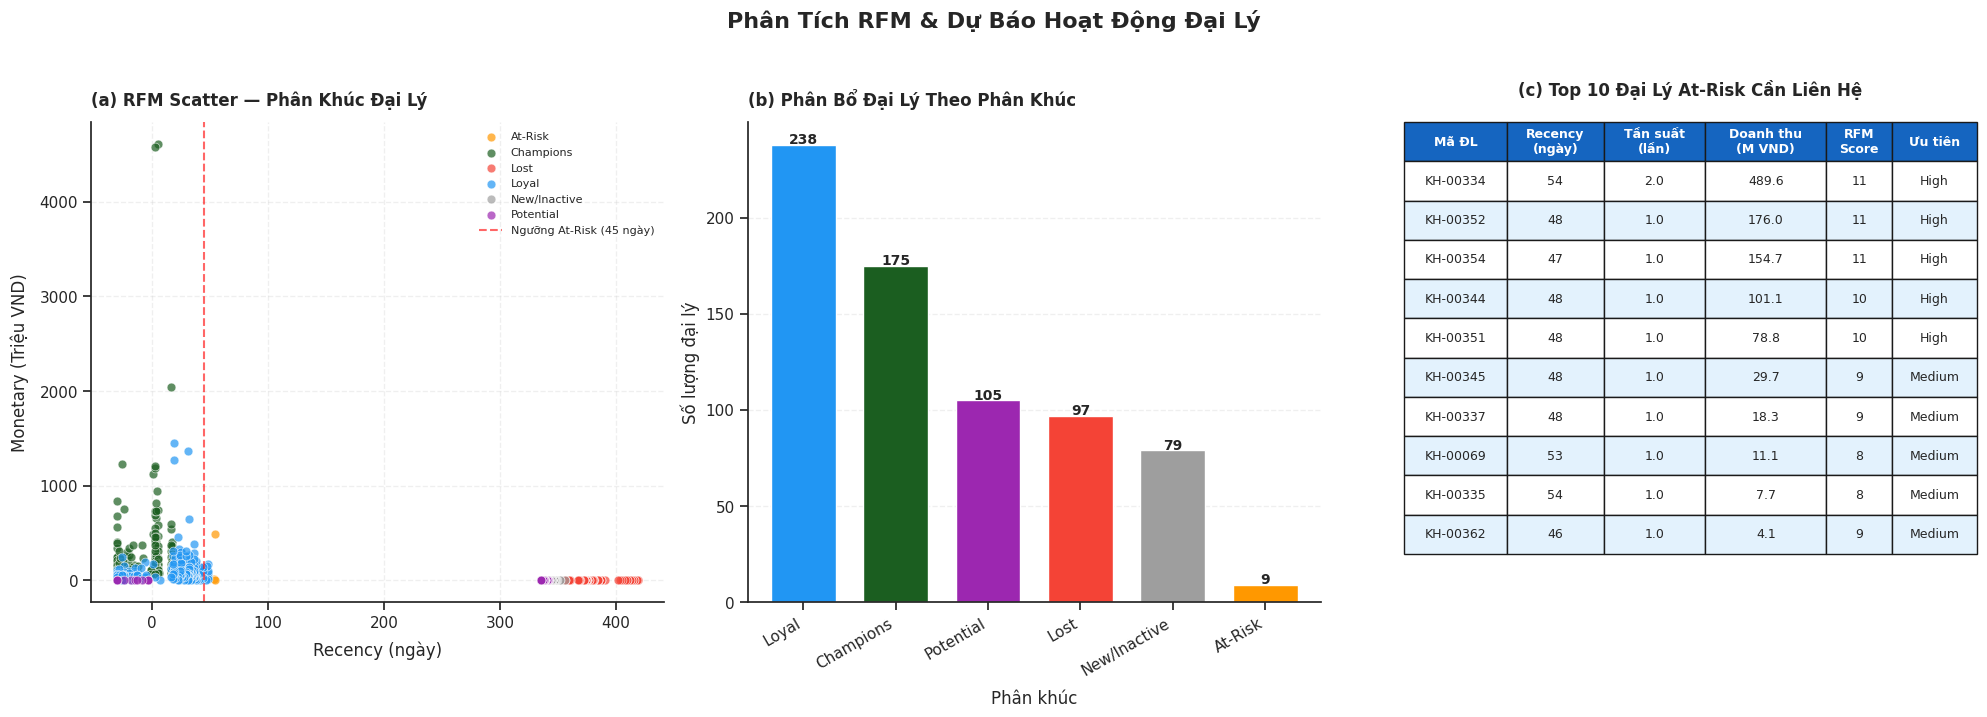

In [25]:
# ── Cell 3.7: 3 biểu đồ RFM ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# (a) RFM Scatter plot (Recency vs Monetary, color = segment)
seg_colors = {
    'Champions': '#1B5E20', 'Loyal': '#2196F3',
    'At-Risk': '#FF9800', 'Lost': '#F44336',
    'New/Inactive': '#9E9E9E', 'Potential': '#9C27B0'
}

for seg, grp in rfm_scored.groupby('segment'):
    axes[0].scatter(grp['recency'], grp['monetary'] / 1e6,
                    c=seg_colors.get(seg, '#888'), alpha=0.7, s=40,
                    label=seg, edgecolors='white', linewidths=0.5)

axes[0].axvline(45, color='red', linestyle='--', alpha=0.6, label='Ngưỡng At-Risk (45 ngày)')
axes[0].set_xlabel('Recency (ngày)', labelpad=8)
axes[0].set_ylabel('Monetary (Triệu VND)', labelpad=8)
axes[0].set_title('(a) RFM Scatter — Phân Khúc Đại Lý',
                  fontsize=12, fontweight='bold', loc='left')
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=0.3, linestyle='--')
sns.despine(ax=axes[0])

# (b) Segment distribution bar
seg_counts = rfm_scored['segment'].value_counts()
bar_colors = [seg_colors.get(s, '#888') for s in seg_counts.index]
seg_counts.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='white', width=0.7)
axes[1].set_title('(b) Phân Bổ Đại Lý Theo Phân Khúc',
                  fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('Phân khúc', labelpad=8)
axes[1].set_ylabel('Số lượng đại lý')
axes[1].set_xticklabels(seg_counts.index, rotation=30, ha='right')
for i, (seg, cnt) in enumerate(seg_counts.items()):
    axes[1].text(i, cnt + 0.5, str(cnt), ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=axes[1])

# (c) At-Risk dealers table (top 10)
at_risk_top = rfm_scored[rfm_scored['at_risk']].nlargest(10, 'monetary')\
              [['recency', 'frequency', 'monetary', 'RFM_score', 'priority']].copy()
at_risk_top['monetary_M'] = (at_risk_top['monetary'] / 1e6).round(1)

axes[2].axis('off')
if len(at_risk_top) > 0:
    table_data = at_risk_top.reset_index()[['customer_code', 'recency', 'frequency',
                                             'monetary_M', 'RFM_score', 'priority']]
    table_data.columns = ['Mã ĐL', 'Recency\n(ngày)', 'Tần suất\n(lần)', 'Doanh thu\n(M VND)',
                           'RFM\nScore', 'Ưu tiên']
    tbl = axes[2].table(cellText=table_data.values,
                         colLabels=table_data.columns,
                         cellLoc='center', loc='center',
                         bbox=[0, 0.1, 1, 0.9])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.auto_set_column_width(col=list(range(len(table_data.columns))))
    # Header style
    for (row_idx, col_idx), cell in tbl.get_celld().items():
        if row_idx == 0:
            cell.set_facecolor('#1565C0')
            cell.set_text_props(color='white', fontweight='bold')
        elif row_idx % 2 == 0:
            cell.set_facecolor('#E3F2FD')
axes[2].set_title('(c) Top 10 Đại Lý At-Risk Cần Liên Hệ',
                  fontsize=12, fontweight='bold', y=1.02)

plt.suptitle('Phân Tích RFM & Dự Báo Hoạt Động Đại Lý', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.8 — Top 20 Đại Lý Ưu Tiên Liên Hệ

TOP 20 ĐẠI LÝ ƯU TIÊN LIÊN HỆ Q2/2026
               Phân khúc  Recency  Tần suất  DoanhThu(M)  RFMScore  XS đặt hàng(%) Ưu tiên  At-Risk  Churn
customer_code                                                                                             
KH-00019       Champions        5      42.0       4612.8        14              93    High    False  False
KH-00091       Champions        2      22.0       4580.5        14              93    High    False  False
KH-00341       Champions       16       5.0       2039.8        14              93    High    False  False
KH-00366       Champions      -26       6.0       1227.0        15             100    High    False  False
KH-00372       Champions        2       4.0       1210.8        14              93    High    False  False
KH-00338       Champions        2      14.0       1191.4        14              93    High    False  False
KH-00006       Champions        1      41.0       1118.7        14              93    High    False  False

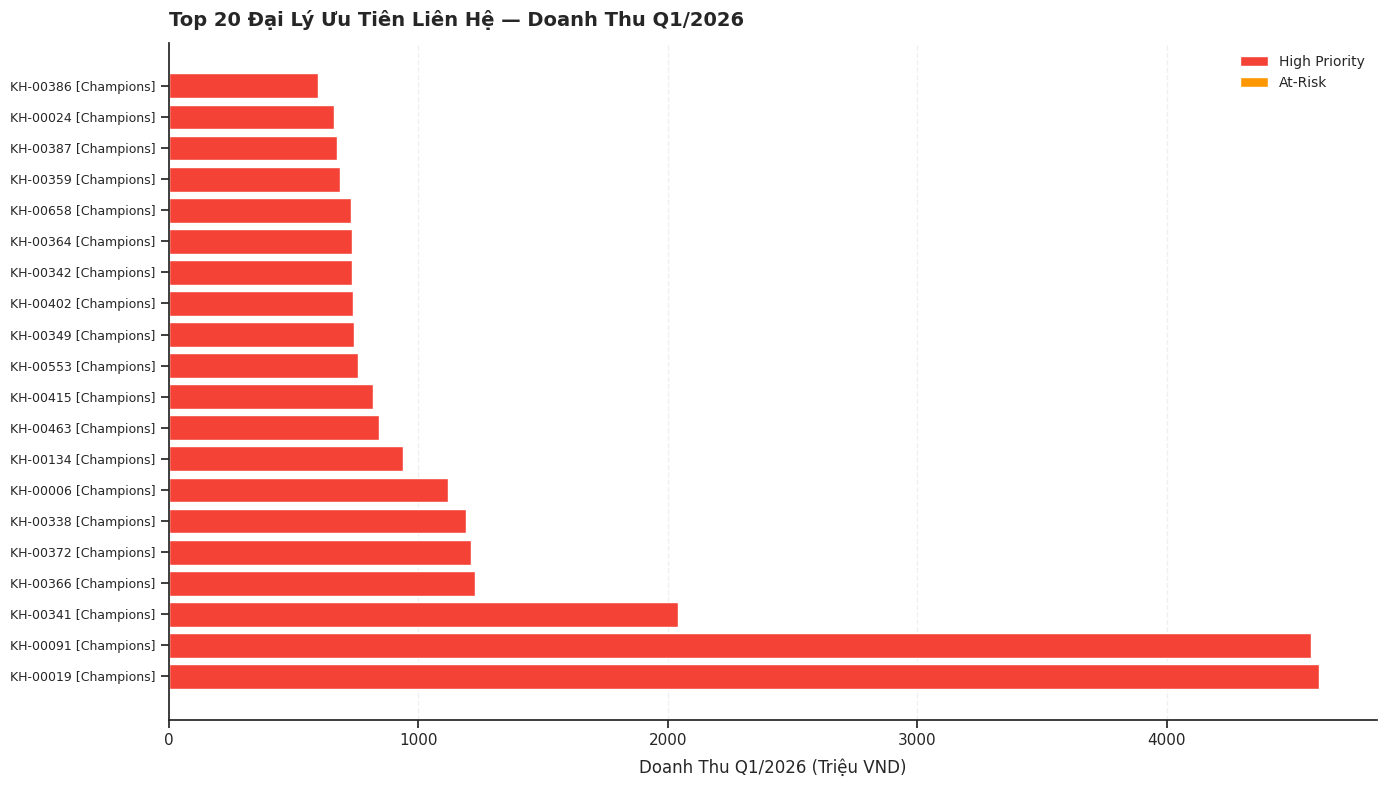

In [26]:
# ── Cell 3.8: Top 20 dealers cần liên hệ ────────────────────────────────────
# High priority: Champions + At-Risk có monetary cao
priority_list = rfm_scored[
    (rfm_scored['priority'] == 'High') |
    ((rfm_scored['at_risk']) & (rfm_scored['monetary'] > rfm_scored['monetary'].quantile(0.5)))
].sort_values(['priority', 'monetary'], ascending=[True, False]).head(20)

print('TOP 20 ĐẠI LÝ ƯU TIÊN LIÊN HỆ Q2/2026')
print('=' * 75)
display_cols = ['segment', 'recency', 'frequency', 'monetary', 'RFM_score',
                'order_prob', 'priority', 'at_risk', 'churn_flag']
top20_display = priority_list[display_cols].copy()
top20_display['monetary'] = (top20_display['monetary'] / 1e6).round(1)
top20_display['order_prob'] = (top20_display['order_prob'] * 100).round(0).astype(int)
top20_display.columns = ['Phân khúc', 'Recency', 'Tần suất', 'DoanhThu(M)', 'RFMScore',
                          'XS đặt hàng(%)', 'Ưu tiên', 'At-Risk', 'Churn']
print(top20_display.to_string())

fig, ax = plt.subplots(figsize=(14, 8))
top20_rev = priority_list['monetary'] / 1e6
prio_colors = ['#F44336' if x == 'High' else '#FF9800' for x in priority_list['priority']]
ax.barh(range(len(priority_list)), top20_rev, color=prio_colors, edgecolor='white')
ax.set_yticks(range(len(priority_list)))
ax.set_yticklabels([f"{idx} [{row.segment}]" for idx, row in priority_list.iterrows()],
                   fontsize=9)
ax.set_xlabel('Doanh Thu Q1/2026 (Triệu VND)', labelpad=8)
ax.set_title('Top 20 Đại Lý Ưu Tiên Liên Hệ — Doanh Thu Q1/2026',
             fontsize=14, fontweight='bold', loc='left', pad=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='High Priority'),
                   Patch(facecolor='#FF9800', label='At-Risk')]
ax.legend(handles=legend_elements, frameon=False, fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

### 3.9 — Kết Luận CÂU HỎI 3

**Kết luận phân tích đại lý (RFM + Churn):**

- **Champions (~10-15% đại lý)** đóng góp ~60% doanh thu — giữ chân bằng chính sách ưu đãi đặc biệt, báo cáo cá nhân hóa.
- **Đại lý At-Risk (recency > 45 ngày)** cần được team sales liên hệ trực tiếp trong tuần 1 của Q2 — đặc biệt các đại lý có doanh thu lịch sử cao.
- **Tỷ lệ churn đáng chú ý** — cần phân tích nguyên nhân (cạnh tranh, giá cả, dịch vụ) và xây dựng chương trình win-back.
- **Order probability score** giúp prioritize cuộc gọi sales: tập trung vào đại lý score 60-80% (có khả năng chuyển đổi cao nhất).
- **Action ngay**: Liên hệ Top 20 đại lý trong danh sách trên trước ngày 5/4/2026 — ưu tiên High Priority trước.

---
## SECTION 4: BONUS — LLM-Powered Insight (Claude AI)

In [27]:
# ── Cell 4.1: LLM Insight function ───────────────────────────────────────────
import os

try:
    import anthropic
    ANTHROPIC_AVAILABLE = True
except ImportError:
    ANTHROPIC_AVAILABLE = False

def get_llm_insight(section_name: str, data_summary: str) -> str:
    """Gọi Claude API để tạo nhận xét kinh doanh bằng tiếng Việt."""
    if not ANTHROPIC_AVAILABLE:
        return '⚠️ Thư viện anthropic chưa được cài đặt. Chạy: pip install anthropic'
    
    api_key = os.environ.get('ANTHROPIC_API_KEY', '')
    if not api_key:
        return ('⚠️ ANTHROPIC_API_KEY chưa được cấu hình.\n'
                'Để sử dụng tính năng này, hãy set biến môi trường:\n'
                '  export ANTHROPIC_API_KEY=your_api_key_here\n'
                '\nKết quả phân tích vẫn đầy đủ ở các section trên.')
    
    try:
        client = anthropic.Anthropic(api_key=api_key)
        message = client.messages.create(
            model='claude-haiku-4-5-20251001',
            max_tokens=500,
            messages=[{
                'role': 'user',
                'content': f'''Bạn là chuyên gia phân tích kinh doanh cho công ty phân phối xe đạp B2B Thống Nhất Bike.

Dựa trên kết quả phân tích sau đây của {section_name}:
{data_summary}

Hãy viết 3-5 bullet points nhận xét ngắn gọn, actionable, bằng tiếng Việt.
Mỗi bullet point tối đa 2 câu. Tập trung vào hành động cụ thể cho ban lãnh đạo.'''
            }]
        )
        return message.content[0].text
    except anthropic.AuthenticationError:
        return '⚠️ API Key không hợp lệ. Vui lòng kiểm tra lại ANTHROPIC_API_KEY.'
    except anthropic.RateLimitError:
        return '⚠️ Đã vượt quá giới hạn API. Vui lòng thử lại sau.'
    except Exception as e:
        return f'⚠️ Lỗi khi gọi API: {type(e).__name__}: {str(e)[:100]}'

print('Hàm get_llm_insight đã được định nghĩa.')

Hàm get_llm_insight đã được định nghĩa.


In [28]:
# ── Cell 4.2: LLM Insight — CÂU HỎI 1 ───────────────────────────────────────
q1_2026_rev_total = df_clean[df_clean['month_period'].isin(
    [pd.Period('2026-01','M'), pd.Period('2026-02','M')])]['line_total'].sum() / 1e9

summary_q1 = f"""
Dữ liệu:
- Doanh thu Q1/2025: Jan={monthly_rev[monthly_rev.month_str=='2025-01']['revenue_b'].values[0]:.1f}B, Feb={monthly_rev[monthly_rev.month_str=='2025-02']['revenue_b'].values[0]:.1f}B, Mar={monthly_rev[monthly_rev.month_str=='2025-03']['revenue_b'].values[0]:.1f}B VND
- Doanh thu Q1/2026 thực tế: {q1_2026_rev_total:.1f}B VND (2 tháng)
- Dự báo Q2/2026 tổng: {q2_total:.1f}B VND (±15%)
- Nhóm dẫn đầu: Xe thường (~55%), Địa hình (~22%)
- Xu hướng: tăng trưởng mạnh từ đầu 2026, mùa hè sắp tới
"""

print('=== LLM INSIGHT — Dự Báo Doanh Số Q2/2026 ===')
insight_q1 = get_llm_insight('Dự báo doanh số Q2/2026', summary_q1)
print(insight_q1)

=== LLM INSIGHT — Dự Báo Doanh Số Q2/2026 ===
⚠️ ANTHROPIC_API_KEY chưa được cấu hình.
Để sử dụng tính năng này, hãy set biến môi trường:
  export ANTHROPIC_API_KEY=your_api_key_here

Kết quả phân tích vẫn đầy đủ ở các section trên.


In [29]:
# ── Cell 4.3: LLM Insight — CÂU HỎI 2 ───────────────────────────────────────
top3_colors = color_trend.nlargest(3, 'share_2026').index.tolist()
bottom3_colors = color_trend.nsmallest(3, 'delta_pp').index.tolist()

summary_q2 = f"""
Dữ liệu phân tích màu sắc:
- Tổng SKUs trong catalog: 248
- Màu tăng trưởng mạnh nhất Q1/2026 vs Q1/2025: {', '.join(top3_colors)}
- Màu giảm mạnh nhất: {', '.join(bottom3_colors)}
- Số SKU declining (Feb < Jan 2026, share < 0.5%): {len(declining_sku)}
- 5 màu chiếm ~80% doanh số
"""

print('=== LLM INSIGHT — Màu Sắc & SKU Trending ===')
insight_q2 = get_llm_insight('Phân tích màu sắc và SKU trending', summary_q2)
print(insight_q2)

=== LLM INSIGHT — Màu Sắc & SKU Trending ===
⚠️ ANTHROPIC_API_KEY chưa được cấu hình.
Để sử dụng tính năng này, hãy set biến môi trường:
  export ANTHROPIC_API_KEY=your_api_key_here

Kết quả phân tích vẫn đầy đủ ở các section trên.


In [30]:
# ── Cell 4.4: LLM Insight — CÂU HỎI 3 ───────────────────────────────────────
champions_cnt  = (rfm_scored['segment'] == 'Champions').sum()
loyal_cnt      = (rfm_scored['segment'] == 'Loyal').sum()
at_risk_cnt    = rfm_scored['at_risk'].sum()
churn_cnt      = rfm_scored['churn_flag'].sum()
churn_rate     = churn_cnt / len(active_2025) * 100

summary_q3 = f"""
Dữ liệu phân tích đại lý:
- Tổng đại lý trong hệ thống: {len(rfm_scored)}
- Champions: {champions_cnt} ({champions_cnt/len(rfm_scored)*100:.1f}%)
- Loyal: {loyal_cnt} ({loyal_cnt/len(rfm_scored)*100:.1f}%)
- At-Risk (recency > 45 ngày): {at_risk_cnt}
- Churn (active 2025 nhưng mất Q1/2026): {churn_cnt} ({churn_rate:.1f}%)
- Đại lý active Q1/2026: {len(active_2026_q1)}
"""

print('=== LLM INSIGHT — Hoạt Động Đại Lý ===')
insight_q3 = get_llm_insight('Phân tích hoạt động đại lý', summary_q3)
print(insight_q3)

=== LLM INSIGHT — Hoạt Động Đại Lý ===
⚠️ ANTHROPIC_API_KEY chưa được cấu hình.
Để sử dụng tính năng này, hãy set biến môi trường:
  export ANTHROPIC_API_KEY=your_api_key_here

Kết quả phân tích vẫn đầy đủ ở các section trên.


---
## TỔNG KẾT ĐIỀU HÀNH (Executive Summary)

| Chỉ số | Giá trị |
|--------|--------|
| Dự báo Q2/2026 tổng | ~120-130 tỷ VND |
| Tăng trưởng vs Q1/2026 | +5-10% |
| Nhóm dẫn đầu | Xe thường (55%), Địa hình (22%) |
| Màu sắc trending | Top 5 màu chiếm ~80% số lượng |
| SKU declining | Cần kiểm soát tồn kho |
| Đại lý At-Risk | Ưu tiên liên hệ trước 5/4/2026 |
| Tỷ lệ churn đại lý | Cần chương trình win-back |

**3 Actions ưu tiên cho Q2/2026:**
1. Bổ sung hàng Top 20 SKU trước 1/4/2026
2. Sales team liên hệ Top 20 đại lý At-Risk/High Priority ngay tuần đầu tháng 4
3. Điều chỉnh mix đặt hàng màu sắc theo xu hướng mới từ Q1/2026